# Inspecting general roll outs

Visualize the expeirment: "general_rollout" (see experiment.py)

We want to validate that our generic opro roll out strategies more or less approximate "brand name" evolutionary search algorithms (e.g., gepa, open_evolve).

- Visualize score evolution over time
- visualize diversity of discovered solutions overtime.

1st visual: 
- 3x6 figure. Columns are tasks (kernelbench, cloudcast, cantbelate, harmbench, prompt+gsm8k, prompt+drop). 
- first row: scatter plot of all 14 different solutions w/ a line connecting the pareto-front of each one. Have the opro variants be shown in various shades of dimmed out blues, let gepa/open_evolve have brighter colors.
- second row: plot an average mean over the max scores across all 14 different optimizers, w/ lighter trajectories for the spread of the max scores for the individual optimizers
- third row: plot an average mean over the scores across all 14 different optimizers, w/ lighter trajectories for the spread of the scores of individual optimizers
- The x-axis shows tokens spent, the y-axis shows score. 

2nd visual:
- do the same visual as above but for semantic diversity (use a code embedding model for code tasks 'Qodo/Qodo-Embed-1-1.5B', sentence embedding model for text tasks: 'all-MiniLM-L6-v2')
- bin diversity at each token position as the average pairwise cosine distance across the last five discovered solutions (windowed approach)


## Figure plan (restated)

**Goal**: validate that generic OPRO roll-out strategies (3 sampling strategies x 4 mutators = 12 configs) approximately recover the score-vs-compute performance of the two purpose-built "brand name" evolutionary search frameworks (GEPA, OpenEvolve) -- i.e. show OPRO isn't leaving performance on the table relative to dedicated algorithms, compared on equal token budget.

**Visual 1 -- score evolution over time**, 3x6 grid:
- Columns = task (kernelbench, cloudcast, cantbelate, harmbench, prompt+gsm8k, prompt+drop)
- Row 1: scatter of all 14 optimizer configs' solutions (score vs. tokens spent) with a pareto-front line per config; OPRO variants in dimmed blues, GEPA/OpenEvolve in brighter distinct colors. Failed/crashed-candidate sentinel scores (kernelbench, cantbelate, cloudcast) are excluded from the scatter.
- Row 2: mean of the running-max score across all 14 optimizers vs. **tokens spent**, with lighter individual-optimizer running-max trajectories underneath ("best found so far" per unit compute)
- Row 3: mean of the running-max score across all 14 optimizers vs. **iteration index** (not tokens), with lighter individual trajectories underneath -- isolates per-iteration convergence from row 2's per-token convergence (optimizers spend different amounts of tokens per iteration)
- Row 1-2 x-axis: cumulative tokens spent. Row 3 x-axis: iteration count. Y-axis: score throughout.

**Visual 2 -- semantic diversity evolution**, same 3x6 layout and rows, but Y-axis is diversity instead of score: windowed average pairwise cosine distance across the last 5 discovered solutions' embeddings (`Qodo/Qodo-Embed-1-1.5B` for code tasks, `all-MiniLM-L6-v2` for text tasks).

**Data notes**:
- Source: `long_running_solution_bank.json` per run dir under `general_rollout/` -- full chronological history, one record per real evaluation event, keyed by contiguous int id. `cumulative_tokens_spent` is strictly increasing in id order, so id order == token-spend order already (no re-sorting needed).
- No deduplication of repeated solution text (open_evolve's island model can independently re-propose identical code) -- every entry is a real eval that spent its own tokens, so it stays in the score-vs-tokens trajectory as-is.
- Two open_evolve runs (cantbelate, cloudcast) can be inflated by job restarts that resumed past their intended `num_iter` (see `_resumable_run` in `llm_optimizer/optimizers/open_evolve.py` -- fixed going forward, but pre-existing on-disk data can still be oversized) -- truncated to `num_iter + 1` records below.
- kernelbench/cantbelate/cloudcast return a fixed sentinel score for a failed/crashed candidate (`failed_score` on the Task subclass) rather than a real low score -- excluded from the row-1 scatter (see `TASK_FAILED_SCORE`), though harmless to leave in the running-max rows since a sentinel never wins the max.


In [1]:
"""Loader for general_rollout run dirs -> ordered (by tokens spent) solution history."""

from __future__ import annotations

import json
import os

EXPERIMENT_DIR = './general_rollout'

# Tasks encoded in each run dir name as '..._{task}_...'; 'prompt' further
# splits into two columns by its trailing benchmark suffix (gsm8k/drop).
TASKS = ['kernelbench', 'cloudcast', 'cantbelate', 'harmbench', 'prompt']
OPTIMIZER_PREFIXES = ['open_evolve', 'gepa', 'opro']

# mutator/sampling_strategy_name vocab (see generate_experiment_args.py's
# get_args_for_roll_outs + main.py's argparse defaults for gepa/
# open_evolve, which don't set these so the argparse defaults
# 'kincontext'/'most_recent' show up in their dir names instead).
# Matched by bounded substring search, NOT dirname.split('_')[i] -- the
# open_evolve prefix is two tokens ('open_evolve') and 'highest_scoring'/
# 'most_recent' each embed their own '_', so positional indices don't
# line up consistently across optimizers. Order matters here: 'GA' is a
# substring of 'GEPA', so try the 4-char value first.
MUTATORS = ['kincontext', 'GEPA', 'DE', 'GA']
SAMPLING_STRATEGIES = ['highest_scoring', 'tournament', 'wheel', 'most_recent']

# num_iter each task was actually launched with (see launch_exps.sh /
# experiments.py default=50) -- used only to detect + truncate runs that
# got inflated by a job restart resuming past their intended budget.
TASK_NUM_ITER = {
    'kernelbench': 50,
    'cloudcast': 200,
    'cantbelate': 200,
    'harmbench': 50,
    'prompt': 50,
}

# Inference-model pin: general_rollout/ (across opro/gepa/open_evolve alike)
# now holds multiple inference-model variants per (task, dataset) for
# prompt AND harmbench -- the original gemma-4B sweep, plus newer
# OLMo-2-0425-1B and Llama-3.2-1B sweeps (see 'adding additional
# inference models' / 'updating general_rollouts to actually use a
# different inference llm for the prompt/harmbench tasks' in git
# history). parse_run_dir below doesn't resolve inference model, so
# multiple variants would silently collide on the same optimizer_label /
# column_key (last one alphabetically wins) -- worse, harmbench's non-
# gemma-4B run dirs are still empty (no long_running_solution_bank.json
# yet, jobs still starting/queued), so leaving them in crashes load_run
# outright rather than just corrupting data. Pin both tasks to the
# original gemma-4B runs everywhere their run dirs get globbed; ignore
# OLMo/Llama-3.2B for now (confirmed with the user, for prompt at least
# -- harmbench included too since it has the identical collision/crash,
# flagged back to the user) until this notebook is extended to facet by
# inference model too. kernelbench/cloudcast/cantbelate only have a
# gemma-4B variant on disk, hence their absence from this dict.
TASK_INFERENCE_MODEL_FILTER: dict[str, str] = {
    'prompt': 'googlegemma-4-E4B-it',
    'harmbench': 'googlegemma-4-E4B-it',
}


def inference_model_ok(dirname_or_path: str, task_token: str) -> bool:
    """True unless `task_token` has a pinned inference model (see
    TASK_INFERENCE_MODEL_FILTER) that `dirname_or_path` doesn't embed.
    """
    inference_model = TASK_INFERENCE_MODEL_FILTER.get(task_token)
    return inference_model is None or f'_{inference_model}_' in dirname_or_path


def parse_run_dir(dirname: str) -> tuple[str, str, str, str, str]:
    """(optimizer_name, task_name, column_key, mutator, sampling_strategy).

    column_key is task_name, except 'prompt' splits into
    'prompt_gsm8k' / 'prompt_drop' (the two benchmarks that task sweeps)
    since those are separate columns in the 3x6 grid. mutator/
    sampling_strategy are always resolved (even for gepa/open_evolve,
    where they're just the unused argparse defaults) so callers don't
    need optimizer-specific branches.
    """
    optimizer_name = next(p for p in OPTIMIZER_PREFIXES if dirname.startswith(p))
    task_name = next(t for t in TASKS if f'_{t}_' in dirname)
    column_key = task_name
    if task_name == 'prompt':
        benchmark = dirname.rsplit('_', 1)[-1]  # 'drop' or 'gsm8k'
        column_key = f'prompt_{benchmark}'
    mutator = next(m for m in MUTATORS if f'_{m}_' in dirname)
    sampling_strategy = next(s for s in SAMPLING_STRATEGIES if f'_{s}_' in dirname)
    return optimizer_name, task_name, column_key, mutator, sampling_strategy


def load_bank(path: str) -> list[dict]:
    """Read a solution_bank.json, ordered ascending by id == tokens spent.

    See figure-plan markdown above: cumulative_tokens_spent is strictly
    increasing in id order (verified against generation_metadata deltas),
    so sorting by int(key) already gives the token-spend-ordered
    trajectory -- no need to re-sort by cumulative_tokens_spent directly.
    """
    with open(path, encoding='utf-8') as f:
        data = json.load(f)
    return [data[str(k)] for k in sorted(int(k) for k in data)]


def load_run(run_dir: str, task_name: str, *, verbose: bool = True) -> list[dict]:
    """load_bank() for one run dir, truncated to num_iter + 1 if inflated.

    Only trims runs that overshot their intended budget (see the
    _resumable_run fix in llm_optimizer/optimizers/open_evolve.py --
    this handles pre-existing on-disk data from before that fix). Does
    NOT deduplicate repeated solution text within the kept range.
    """
    path = os.path.join(run_dir, 'long_running_solution_bank.json')
    records = load_bank(path)
    max_len = TASK_NUM_ITER[task_name] + 1
    if len(records) > max_len:
        if verbose:
            print(
                f'[truncate] {os.path.basename(run_dir)}: '
                f'{len(records)} -> {max_len} records '
                f'(num_iter={TASK_NUM_ITER[task_name]})',
            )
        records = records[:max_len]
    return records


In [2]:
"""Discover all run dirs and load them, grouped by column (task) x optimizer label."""

runs_by_column: dict[str, dict[str, list[dict]]] = {}

for dirname in sorted(os.listdir(EXPERIMENT_DIR)):
    run_dir = os.path.join(EXPERIMENT_DIR, dirname)
    if not os.path.isdir(run_dir):
        continue
    optimizer_name, task_name, column_key, mutator, sampling_strategy = (
        parse_run_dir(dirname)
    )
    # see TASK_INFERENCE_MODEL_FILTER above -- prompt now has 3 inference-
    # model variants on disk per (task, dataset); pin to gemma-4B.
    if not inference_model_ok(dirname, task_name):
        continue
    # opro contributes 12 sub-variants (sampling_strategy x mutator); keep
    # them distinguishable rather than collapsing to 'opro'. gepa/
    # open_evolve don't read mutator/sampling_strategy, so leave those as
    # the single label they already are.
    optimizer_label = optimizer_name
    if optimizer_name == 'opro':
        optimizer_label = f'opro_{mutator}_{sampling_strategy}'

    records = load_run(run_dir, task_name)
    runs_by_column.setdefault(column_key, {})[optimizer_label] = records

print(f'{len(runs_by_column)} columns loaded:')
for column_key, optimizers in runs_by_column.items():
    print(f'  {column_key:14s} {len(optimizers)} optimizer configs')

6 columns loaded:
  cantbelate     10 optimizer configs
  cloudcast      11 optimizer configs
  kernelbench    10 optimizer configs
  prompt_drop    14 optimizer configs
  prompt_gsm8k   14 optimizer configs
  harmbench      14 optimizer configs


## Visual 1: score evolution over tokens spent

**Color plan** (validated against `dataviz` skill's reference palette,
`references/palette.md`): row 1 is a scatter (all-pairs comparison, not just
adjacent series), and only the palette's first three categorical slots
(blue / orange / aqua) clear all-pairs CVD separation in both light and dark
mode -- so those three are what's available for genuinely distinct hues here.
The 12 OPRO sub-variants (4 mutators x 3 sampling strategies) aren't meant to
be individually legible per the original spec ("various shades of dimmed out
blues") -- they get lightness steps off the single-hue **sequential blue
ramp** instead, so they read as one hazy family. GEPA takes slot 2 (orange),
OpenEvolve takes slot 3 (aqua) -- both fully saturated so they visually pop
out of the blue cloud. Rows 2-3 are statistical summaries (mean +
per-optimizer spread), not identity comparisons, so the bold "mean across all
14" line uses primary ink (neutral), with each optimizer's own trajectory
underneath at low alpha in its row-1 color -- same color language throughout
the figure, mean de-emphasized-vs-emphasized by weight/opacity rather than a
new hue.


In [3]:
"""Palette + shared plotting helpers (see color-plan markdown above)."""

import itertools

import matplotlib.pyplot as plt
import numpy as np

# --- Chart chrome (dataviz skill references/palette.md, light mode) ---
SURFACE = '#fcfcfb'
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'

# --- Categorical slots 1-3 (only trio that clears all-pairs CVD gates --
# needed here since row 1 is a scatter, i.e. an all-pairs comparison) ---
COLOR_GEPA = '#eb6834'  # slot 2, orange
COLOR_OPEN_EVOLVE = '#1baf7a'  # slot 3, aqua

# --- Sequential blue ramp, 12 steps (dropping the lightest step '100' --
# too close to the surface to read) -- one per OPRO sub-variant, assigned
# by a fixed canonical order so a given (mutator, sampling_strategy) always
# gets the same shade across every column ("color follows the entity") ---
BLUE_RAMP = [
    '#b7d3f6', '#9ec5f4', '#86b6ef', '#6da7ec', '#5598e7', '#3987e5',
    '#2a78d6', '#256abf', '#1c5cab', '#184f95', '#104281', '#0d366b',
]
OPRO_MUTATORS_CANON = ['kincontext', 'DE', 'GA', 'GEPA']
OPRO_STRATEGIES_CANON = ['highest_scoring', 'tournament', 'wheel']
OPRO_VARIANT_ORDER = [
    f'opro_{mutator}_{strategy}'
    for strategy, mutator in itertools.product(
        OPRO_STRATEGIES_CANON,
        OPRO_MUTATORS_CANON,
    )
]
OPRO_COLOR_BY_LABEL = dict(zip(OPRO_VARIANT_ORDER, BLUE_RAMP, strict=True))


def color_for(optimizer_label: str) -> str:
    """Resolve an optimizer_label (from the loader cells) to its color."""
    if optimizer_label == 'gepa':
        return COLOR_GEPA
    if optimizer_label == 'open_evolve':
        return COLOR_OPEN_EVOLVE
    return OPRO_COLOR_BY_LABEL[optimizer_label]


# --- Column order + display titles (matches the original 3x6 spec) ---
COLUMN_ORDER = [
    'kernelbench', 'cloudcast', 'cantbelate',
    'harmbench', 'prompt_gsm8k', 'prompt_drop',
]
COLUMN_TITLES = {
    'kernelbench': 'KernelBench',
    'cloudcast': 'CloudCast',
    'cantbelate': 'CantBeLate',
    'harmbench': 'HarmBench',
    'prompt_gsm8k': 'Prompt (GSM8K)',
    'prompt_drop': 'Prompt (DROP)',
}


def task_for_column(column_key: str) -> str:
    """column_key -> task_name (undoes the prompt_gsm8k/prompt_drop split)."""
    return 'prompt' if column_key.startswith('prompt_') else column_key


# --- Sentinel scores for a failed/crashed candidate (see
# llm_optimizer/tasks/{kernel_bench,cant_be_late,cloud_cast}.py's
# failed_score / FAILED_SCORE) -- not a low real score, so it's excluded
# from the row-1 scatter rather than plotted as data. harmbench/prompt
# have no such sentinel (absent from this dict -> nothing filtered). ---
TASK_FAILED_SCORE = {
    'kernelbench': -1.0,
    'cantbelate': -100_000.0,
    'cloudcast': -100_000.0,
}


def running_max(values: np.ndarray) -> np.ndarray:
    """Best score found so far, at each step -- also the row-1 pareto front."""
    return np.maximum.accumulate(values)


def step_interpolate(xs: np.ndarray, ys: np.ndarray, grid: np.ndarray) -> np.ndarray:
    """Forward-fill ys(xs) onto grid: value as of the last eval at/before g.

    NaN before xs[0] (no eval yet at that token count) -- callers use
    np.nanmean so runs that haven't reached a grid point yet are excluded
    from the mean there rather than treated as zero. Grid points AFTER
    xs[-1] are NOT NaN -- idx clips to len(ys)-1, so it holds ys[-1] flat.
    Callers that want a mean line to extend as far as the longest variant
    (rather than stopping at the shortest) rely on this: a variant that
    hasn't spent more tokens yet still correctly reports its best-so-far
    score at any later token count, so extrapolating the grid past a
    shorter variant's current end is honest, not fabricated.
    """
    idx = np.searchsorted(xs, grid, side='right') - 1
    out = np.where(idx >= 0, ys[np.clip(idx, 0, len(ys) - 1)], np.nan)
    return out


def pad_to_length(values: np.ndarray, length: int) -> np.ndarray:
    """Forward-fill (repeat the last value) to extend a running-max array to
    `length` -- the iteration-indexed analog of step_interpolate's flat
    extrapolation past a shorter variant's current end, for callers that
    align by raw index instead of resampling onto a token grid.
    """
    if len(values) >= length:
        return values[:length]
    pad = np.full(length - len(values), values[-1])
    return np.concatenate([values, pad])


def tokens_fmt(x: float, _pos: int | None = None) -> str:
    """Tick formatter: cumulative_tokens_spent in human-readable k/M."""
    if x >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    if x >= 1_000:
        return f'{x / 1_000:.0f}k'
    return f'{x:.0f}'


In [4]:
"""Curated seed-population overlay for Visual 1 (all 6 columns).

For each population saved under curated_initial_populations_by_iter_budget/
<task>/budget_N/Row_i_Col_j.json (the curation notebook's static seed pools --
NOT a live population_dynamics run), plot that population's own best score
as a red dot:
- Row 2 x = token cost of building that budget's candidate pool (summed
  cumulative_tokens_spent, at iteration <= budget, across every opro_*
  general_rollout run for that task) -- same "cost" definition as
  Multi_Tasks_Curating_Initial_Populations_By_Iteration_Budget.ipynb's
  load_pool_from_opro_runs_by_budget, reimplemented here since that
  notebook doesn't persist a cost manifest to disk.
- Row 3 x = the iteration-equivalent cost of building that pool, i.e.
  budget * num_trajectories_pooled (confirmed with the user): a budget-N
  pool isn't one trajectory running N iterations, it's N iterations
  pooled from every one of the ~12 independent opro trajectories that fed
  it -- mirroring row 2's cost_tokens, which is likewise a SUM across all
  pooled trajectories, not one trajectory's own spend. Stored as
  'iter_cost' (distinct from 'budget', the raw N, which is kept around
  since it's still needed to skip exactly N iterations' worth of pooled
  history when matching population_dynamics runs downstream).
- y (both rows) = max score among that population's own pop_size solutions.

Each point also records num_seeds (= len(pop), the exact seed-solution
count for THIS specific file -- confirmed NOT constant: 5 for kernelbench/
cloudcast/cantbelate/harmbench, but 7-10 for the two prompt tasks depending
on budget, since thin early budgets fall back to a smaller sampled
population) and source_path (this file's on-disk path), both consumed by
the population-dynamics continuation overlay in the next cell.

column_key != general_rollout's task_token for the two prompt columns --
'prompt_drop'/'prompt_gsm8k' are curated as their own on-disk task dirs
(and are the column_key everywhere else in this notebook), but general_
rollout's run dirs use task_token='prompt' with a trailing '_drop'/
'_gsm8k' benchmark suffix instead (mirrors generate_experiment_args.py's
POP_DYNAMICS_TASK_MAP). CURATED_POP_TASK_MAP resolves column_key ->
(task_token, dataset) for the cost lookup; every other column defaults to
(column_key, None) via .get.

Not every budget the curation notebook's TASK_BUDGET_CONFIGS lists has
actually been (re)generated under curated_initial_populations_by_iter_budget/
yet (a fuller set exists in the sibling
curated_initial_populations_by_iter_budget_scratch/ dir) -- this overlay
only ever shows what's really on disk here, so a sparse column just means
fewer red dots, not a bug.
"""

import glob

CURATED_POP_DIR = '/scratch/mansisak/llm_optimizer/curated_initial_populations_by_iter_budget'
CURATED_POP_TASKS = list(COLUMN_ORDER)  # overlay every column
COLOR_CURATED_POP = '#d6273c'  # red, reserved for this overlay only

CURATED_POP_TASK_MAP: dict[str, tuple[str, str | None]] = {
    'prompt_drop': ('prompt', 'drop'),
    'prompt_gsm8k': ('prompt', 'gsm8k'),
}


def compute_cost_tokens(
    task_token: str, budget: int, dataset: str | None = None,
) -> tuple[int, int]:
    """(total_cost_tokens, num_trajectories_pooled) for this task's opro pool
    through iteration `budget`. total_cost_tokens sums cumulative_tokens_spent
    across every opro_* general_rollout run dir for that task (and, for
    prompt, that `dataset` benchmark, pinned to gemma-4B -- see
    TASK_INFERENCE_MODEL_FILTER) -- same definition as the curation
    notebook's load_pool_from_opro_runs_by_budget, reimplemented here since
    that notebook doesn't persist its computed cost anywhere on disk.
    num_trajectories_pooled is just len(run_dirs) -- how many independent
    opro rollouts (3 sampling_strategies x 4 mutators, currently always 12)
    were run in parallel to build this budget's pool, needed by callers
    that want an iteration-equivalent cost (budget * num_trajectories)
    rather than one trajectory's own raw iteration count.
    """
    run_dirs = glob.glob(os.path.join(EXPERIMENT_DIR, f'opro_*_{task_token}_*/'))
    if dataset is not None:
        run_dirs = [d for d in run_dirs if d.rstrip('/').endswith(f'_{dataset}')]
    run_dirs = [d for d in run_dirs if inference_model_ok(d, task_token)]
    total_cost_tokens = 0
    for run_dir in run_dirs:
        bank_path = os.path.join(run_dir, 'long_running_solution_bank.json')
        if not os.path.exists(bank_path):
            continue
        with open(bank_path, encoding='utf-8') as f:
            bank = json.load(f)
        in_budget_keys = [int(k) for k in bank if int(k) <= budget]
        if in_budget_keys:
            last_key = str(max(in_budget_keys))
            total_cost_tokens += bank[last_key].get('cumulative_tokens_spent', 0) or 0
    return total_cost_tokens, len(run_dirs)


def load_curated_population_points(column_key: str) -> list[dict]:
    """One point per saved Row_i_Col_j.json under every budget_N/ for `column_key`."""
    task_token, dataset = CURATED_POP_TASK_MAP.get(column_key, (column_key, None))
    task_dir = os.path.join(CURATED_POP_DIR, column_key)
    points = []
    if not os.path.isdir(task_dir):
        return points
    for budget_dirname in sorted(os.listdir(task_dir)):
        if not budget_dirname.startswith('budget_'):
            continue
        budget = int(budget_dirname.split('_')[1])
        cost_tokens, num_trajectories = compute_cost_tokens(
            task_token, budget, dataset=dataset,
        )
        budget_dir = os.path.join(task_dir, budget_dirname)
        for fname in sorted(os.listdir(budget_dir)):
            if not fname.endswith('.json'):
                continue
            source_path = os.path.join(budget_dir, fname)
            with open(source_path, encoding='utf-8') as f:
                pop = json.load(f)
            if not pop:
                continue
            max_score = max(v['score'] for v in pop.values())
            points.append({
                'budget': budget,
                'iter_cost': budget * num_trajectories,
                'cost_tokens': cost_tokens,
                'max_score': max_score,
                'pop_key': fname.removesuffix('.json'),
                'num_seeds': len(pop),
                'source_path': source_path,
            })
    return points


curated_points_by_task = {
    column_key: load_curated_population_points(column_key)
    for column_key in CURATED_POP_TASKS
}
for column_key, points in curated_points_by_task.items():
    budgets = sorted({p['budget'] for p in points})
    print(f'{column_key:14s} {len(points)} curated populations across budgets {budgets}')


kernelbench    2 curated populations across budgets [3]
cloudcast      4 curated populations across budgets [2, 3]
cantbelate     5 curated populations across budgets [2, 3, 10]
harmbench      2 curated populations across budgets [2]
prompt_gsm8k   4 curated populations across budgets [2, 3]
prompt_drop    4 curated populations across budgets [2, 5]


In [5]:
"""Population-dynamics continuation overlay: for each red dot (curated seed
population), load whichever of its 12 opro sibling runs under
population_dynamics/ have actually executed, skip each one's copied-in seed
entries, and prep a continuation trajectory from the red dot.

Matching: population_dynamics/'s run-dir naming embeds every CLI arg
(main.py:280-284) the same way general_rollout/'s does, PLUS
init_population_path flattened in (slashes/dots stripped, exactly like
main.py does) -- so a red dot's own source_path, cleaned the same way, is
a reliable substring to isolate its <=12 sibling runs out of every other
population sharing that task. parse_run_dir (defined above, already used
for general_rollout/) resolves each match's mutator/sampling_strategy the
same bounded-substring way; reused as-is since population_dynamics' extra
embedded-path tokens don't collide with the mutator/sampling_strategy
vocab it searches for (verified: none of 'budget_N'/'Row_i_Col_j'/task
names contain a bounded '_DE_'/'_GA_'/'_wheel_'/etc. substring).

NOTE: this flattened-dirname matching only applies to red dots curated
under curated_initial_populations_by_iter_budget/ (the ones this cell
handles) -- main.py has since stopped flattening init_population_path
into the parent dirname (NAME_MAX fix) for newer runs seeded from
curated_initial_populations_tournament_rejection/, which instead mirror
it as real nested subdirectories. See the rejection-overlay cell below
(after the mustard-dot loader) for that scheme's own matcher.

Seed handling (confirmed with the user): don't plot the copied-in seed
solutions themselves. Running max is computed over the FULL bank (seeds +
new solutions) so a new candidate that hasn't yet beaten the seed pool's
own best still correctly shows that best -- then sliced to just the
post-seed portion for plotting.

Offset (confirmed with the user): row 2 (tokens) = red_dot.cost_tokens +
this run's own cumulative_tokens_spent -- already exactly "new tokens
spent since initialization" with no seed contribution (verified against
opro.py's SolutionBank: copied seed entries carry no
cumulative_tokens_spent key at all, so read_from_checkpoint's
.get(..., 0) fallback starts the running total at 0, and it only ever
increments inside add_solution_score_pair, which seed entries never pass
through -- empirically double-checked by re-summing generation_metadata
deltas by hand against the stored field, exact match at every step).
Row 3 (iteration) = red_dot.iter_cost (budget * num_trajectories_pooled,
see the loader cell above -- NOT raw budget, since a budget-N pool was
built from N iterations pooled across ~12 independent trajectories, not
one) + local new-solution index, 1-indexed so the first new solution
lands one iteration past the red dot.
"""

POP_DYNAMICS_DIR = 'population_dynamics'
COLOR_POP_DYNAMICS = '#6a3d9a'  # opaque dark purple, reserved for this overlay


def find_population_dynamics_runs(column_key: str, source_path: str) -> dict[str, str]:
    """optimizer_label ('opro_{mutator}_{strategy}') -> run dir, for one red dot."""
    task_token, dataset = CURATED_POP_TASK_MAP.get(column_key, (column_key, None))
    needle = source_path.replace('.', '').replace('/', '')
    candidates = glob.glob(os.path.join(POP_DYNAMICS_DIR, f'opro_*_{task_token}_*/'))
    if dataset is not None:
        candidates = [d for d in candidates if d.rstrip('/').endswith(f'_{dataset}')]
    candidates = [d for d in candidates if inference_model_ok(d, task_token)]
    runs = {}
    for run_dir in candidates:
        dirname = os.path.basename(run_dir.rstrip('/'))
        if needle not in dirname:
            continue
        _optimizer_name, _task_name, _column_key, mutator, sampling_strategy = (
            parse_run_dir(dirname)
        )
        runs[f'opro_{mutator}_{sampling_strategy}'] = run_dir
    return runs


def load_pop_dynamics_trajectory(
    run_dir: str, num_seeds: int, cost_offset: float, iter_offset: int,
) -> dict[str, np.ndarray] | None:
    """Continuation trajectory (abs tokens/iterations/running-max score) for
    the post-seed portion of one variant run. None if it hasn't produced
    any new (post-seed) solutions yet.
    """
    bank_path = os.path.join(run_dir, 'long_running_solution_bank.json')
    if not os.path.exists(bank_path):
        return None
    records = load_bank(bank_path)  # ordered by key, seeds first
    if len(records) <= num_seeds:
        return None

    own_tokens = np.array(
        [r.get('cumulative_tokens_spent') or 0 for r in records], dtype=float,
    )
    scores = np.array([r['score'] for r in records], dtype=float)
    cummax = running_max(scores)  # over the FULL bank (seeds included)

    n_new = len(records) - num_seeds
    return {
        'tokens': cost_offset + own_tokens[num_seeds:],
        'iters': iter_offset + np.arange(1, n_new + 1),
        'scores': cummax[num_seeds:],
    }


for column_key, points in curated_points_by_task.items():
    for point in points:
        runs = find_population_dynamics_runs(column_key, point['source_path'])
        variants = []
        for optimizer_label, run_dir in runs.items():
            traj = load_pop_dynamics_trajectory(
                run_dir, point['num_seeds'], point['cost_tokens'], point['iter_cost'],
            )
            if traj is not None:
                variants.append({'label': optimizer_label, **traj})
        point['variants'] = variants
        print(
            f"{column_key:14s} budget={point['budget']:<3d} "
            f"iter_cost={point['iter_cost']:<4d} {point['pop_key']:12s} "
            f'{len(variants):2d}/{len(runs):2d} matched variants have new solutions',
        )


kernelbench    budget=3   iter_cost=24   Row_2_Col_1   7/ 7 matched variants have new solutions
kernelbench    budget=3   iter_cost=24   Row_2_Col_2   6/ 6 matched variants have new solutions
cloudcast      budget=2   iter_cost=18   Row_2_Col_1   8/ 8 matched variants have new solutions
cloudcast      budget=2   iter_cost=18   Row_2_Col_2  10/10 matched variants have new solutions
cloudcast      budget=3   iter_cost=27   Row_2_Col_1  10/10 matched variants have new solutions
cloudcast      budget=3   iter_cost=27   Row_2_Col_2  10/10 matched variants have new solutions
cantbelate     budget=10  iter_cost=80   Row_4_Col_1   8/ 8 matched variants have new solutions
cantbelate     budget=2   iter_cost=16   Row_2_Col_1   8/ 8 matched variants have new solutions
cantbelate     budget=2   iter_cost=16   Row_2_Col_2   8/ 8 matched variants have new solutions
cantbelate     budget=3   iter_cost=24   Row_2_Col_1   8/ 8 matched variants have new solutions
cantbelate     budget=3   iter_cost=24  

In [6]:
"""Tournament / diversity-rejection seed-population overlay for Visual 1 (all 6 columns).

Same idea as the curated (red-dot) overlay above, but sourced from
curated_initial_populations_tournament_rejection/<task>/budget_N/{tournament_K<k>|
rejection_B<b>}.json -- the two new within-budget sampling strategies (tournament
selection, diversity-based rejection sampling) from
Multi_Tasks_Curating_Initial_Populations_Tournament_And_Rejection_Sampling.ipynb.

Point shape mirrors load_curated_population_points's, including num_seeds/
source_path -- 'rejection' points need both to match + offset their
population_dynamics continuation trajectories (see the rejection-overlay
cell below). Tournament points get the same fields for consistency even
though they're still intentionally never plotted (per the user). Rejection
points additionally get 'b_threshold' (parsed from pop_key) -- the
diversity_rejection_sampling similarity threshold B that produced that
specific population, consumed by the row-2 panel drawer below to color
each mustard dot's mean pop-dynamics line by how strict/loose its
diversity constraint was (confirmed with the user: exploring whether
initial-population diversity predicts downstream success).

'seed_score_sum' (confirmed with the user, consumed by Fig B's per-bar
'mean' annotation): sum of every solution's score in this population's own
seed file (num_seeds items, NOT yet the max_population_size=20 cap -- see
generate_experiment_args.py's get_args_for_roll_outs/get_args_for_
population_dynamics_roll_outs, both of which pass max_population_size=20
straight through to every OPRO run, general_rollout and population_dynamics
alike). Left as a raw sum rather than pre-divided by anything here since
different callers want different denominators (Fig B divides by the fixed
cap 20, not num_seeds -- a thinner-than-full seed pool is meant to read as
worse, not merely as a smaller-N average of what's there).
"""

STRATEGY_POP_DIR = '/scratch/mansisak/llm_optimizer/curated_initial_populations_tournament_rejection'
COLOR_TOURNAMENT_POP = '#4f9d3c'  # green, reserved for this overlay only
COLOR_REJECTION_POP = '#c9962f'  # mustard, reserved for this overlay only


def parse_rejection_b(pop_key: str) -> float:
    """Diversity threshold B from a rejection point's own pop_key
    ('rejection_B0.954' -> 0.954). Lower B = stricter diversity
    constraint (more candidates rejected as too-similar); B=1.0 = no
    constraint at all (plain top-N-by-score, see the curation notebook).
    """
    return float(pop_key.removeprefix('rejection_B'))


def load_strategy_population_points(column_key: str) -> dict[str, list[dict]]:
    """{'tournament': [...], 'rejection': [...]}, one point per
    {tournament_K<k>|rejection_B<b>}.json under every budget_N/ for `column_key`.
    """
    task_token, dataset = CURATED_POP_TASK_MAP.get(column_key, (column_key, None))
    task_dir = os.path.join(STRATEGY_POP_DIR, column_key)
    points_by_strategy: dict[str, list[dict]] = {'tournament': [], 'rejection': []}
    if not os.path.isdir(task_dir):
        return points_by_strategy

    for budget_dirname in sorted(os.listdir(task_dir)):
        if not budget_dirname.startswith('budget_'):
            continue
        budget = int(budget_dirname.split('_')[1])
        cost_tokens, num_trajectories = compute_cost_tokens(
            task_token, budget, dataset=dataset,
        )
        budget_dir = os.path.join(task_dir, budget_dirname)
        for fname in sorted(os.listdir(budget_dir)):
            if fname.startswith('tournament_'):
                strategy = 'tournament'
            elif fname.startswith('rejection_'):
                strategy = 'rejection'
            else:
                continue
            source_path = os.path.join(budget_dir, fname)
            with open(source_path, encoding='utf-8') as f:
                pop = json.load(f)
            if not pop:
                continue
            max_score = max(v['score'] for v in pop.values())
            pop_key = fname.removesuffix('.json')
            point = {
                'budget': budget,
                'iter_cost': budget * num_trajectories,
                'cost_tokens': cost_tokens,
                'max_score': max_score,
                'seed_score_sum': sum(v['score'] for v in pop.values()),
                'pop_key': pop_key,
                'num_seeds': len(pop),
                'source_path': source_path,
            }
            if strategy == 'rejection':
                point['b_threshold'] = parse_rejection_b(pop_key)
            points_by_strategy[strategy].append(point)
    return points_by_strategy


strategy_points_by_task = {
    column_key: load_strategy_population_points(column_key)
    for column_key in COLUMN_ORDER
}
for column_key, by_strategy in strategy_points_by_task.items():
    n_tournament = len(by_strategy['tournament'])
    n_rejection = len(by_strategy['rejection'])
    print(
        f'{column_key:14s} {n_tournament} tournament + {n_rejection} rejection '
        'populations',
    )


kernelbench    0 tournament + 13 rejection populations
cloudcast      0 tournament + 21 rejection populations
cantbelate     0 tournament + 30 rejection populations
harmbench      0 tournament + 20 rejection populations
prompt_gsm8k   0 tournament + 20 rejection populations
prompt_drop    0 tournament + 20 rejection populations


In [7]:
"""Rejection-seed population-dynamics continuation overlay for Visual 1.

For each mustard dot (diversity-rejection seed population, see the loader
cell above), trace whichever of its opro sibling runs under
population_dynamics/ have actually executed, and prep a continuation
trajectory -- same mechanics as the red dots' overlay two cells up
(load_pop_dynamics_trajectory is reused unchanged), but a DIFFERENT run-dir
matching scheme: these runs were launched after main.py stopped flattening
init_population_path into the parent run dirname (see
experiments/population_dynamics_launch_exps.sh's POP_DIR ->
curated_initial_populations_tournament_rejection/, and main.py's NAME_MAX
fix -- confirmed with the user this is a real, intentional divergence
between the two population_dynamics/ naming eras, not a bug). Instead,
init_population_path is mirrored as REAL nested subdirectories:

  population_dynamics/<config_dir>/curated_initial_populations_tournament_rejection/
      <task_token>/budget_<N>/<pop_key>/long_running_solution_bank.json

where <config_dir> is the same flattened-CLI-args dirname parse_run_dir
already parses (mutator/sampling_strategy resolution is unaffected -- only
the population-path embedding changed), and <pop_key> is exactly the
mustard dot's own 'pop_key' (e.g. 'rejection_B0.956') -- a direct path
join + exists() check, no needle/substring matching against the dirname
needed.

Only run for 'rejection' points -- tournament pools are intentionally
never plotted (per the user). Currently only cantbelate/cloudcast have any
matching runs on disk (population_dynamics_launch_exps.sh's Job B,
in progress) -- every other column's rejection points just get an empty
'variants' list, same "sparse column, not a bug" stance as the loaders
above.
"""

COLOR_REJECTION_POP_DYNAMICS = '#8a6d1f'  # dark olive/mustard, reserved for this overlay


def find_rejection_population_dynamics_runs(
    column_key: str, budget: int, pop_key: str,
) -> dict[str, str]:
    """optimizer_label ('opro_{mutator}_{strategy}') -> bank dir, for one mustard dot."""
    task_token, dataset = CURATED_POP_TASK_MAP.get(column_key, (column_key, None))
    candidates = glob.glob(os.path.join(POP_DYNAMICS_DIR, f'opro_*_{task_token}_*/'))
    if dataset is not None:
        candidates = [d for d in candidates if d.rstrip('/').endswith(f'_{dataset}')]
    candidates = [d for d in candidates if inference_model_ok(d, task_token)]

    runs = {}
    for run_dir in candidates:
        bank_dir = os.path.join(
            run_dir, 'curated_initial_populations_tournament_rejection',
            task_token, f'budget_{budget}', pop_key,
        )
        if not os.path.exists(os.path.join(bank_dir, 'long_running_solution_bank.json')):
            continue
        dirname = os.path.basename(run_dir.rstrip('/'))
        _optimizer_name, _task_name, _column_key, mutator, sampling_strategy = (
            parse_run_dir(dirname)
        )
        runs[f'opro_{mutator}_{sampling_strategy}'] = bank_dir
    return runs


for column_key, by_strategy in strategy_points_by_task.items():
    for point in by_strategy['rejection']:
        runs = find_rejection_population_dynamics_runs(
            column_key, point['budget'], point['pop_key'],
        )
        variants = []
        for optimizer_label, bank_dir in runs.items():
            traj = load_pop_dynamics_trajectory(
                bank_dir, point['num_seeds'], point['cost_tokens'], point['iter_cost'],
            )
            if traj is not None:
                variants.append({'label': optimizer_label, **traj})
        point['variants'] = variants
        if runs:
            print(
                f"{column_key:14s} budget={point['budget']:<3d} "
                f"iter_cost={point['iter_cost']:<4d} {point['pop_key']:14s} "
                f'{len(variants):2d}/{len(runs):2d} matched variants have new solutions',
            )


cloudcast      budget=2   iter_cost=18   rejection_B0.888 12/12 matched variants have new solutions
cloudcast      budget=2   iter_cost=18   rejection_B0.892 12/12 matched variants have new solutions
cloudcast      budget=2   iter_cost=18   rejection_B0.905 12/12 matched variants have new solutions
cloudcast      budget=2   iter_cost=18   rejection_B0.909 12/12 matched variants have new solutions
cloudcast      budget=2   iter_cost=18   rejection_B0.918 12/12 matched variants have new solutions
cloudcast      budget=2   iter_cost=18   rejection_B0.923 12/12 matched variants have new solutions
cloudcast      budget=2   iter_cost=18   rejection_B1.000 12/12 matched variants have new solutions
cloudcast      budget=3   iter_cost=27   rejection_B0.888 12/12 matched variants have new solutions
cloudcast      budget=3   iter_cost=27   rejection_B0.889 12/12 matched variants have new solutions
cloudcast      budget=3   iter_cost=27   rejection_B0.905 12/12 matched variants have new solutions


In [8]:
"""Shared row-2 panel drawer: mean running-max score vs tokens spent, for
one column, with every Visual 1 overlay. Factored out so the combined 3x6
figure's row 2 and the standalone per-task figures below call the exact
same drawing code rather than two copies that can drift out of sync.
Self-contained (re-derives trajectories/curated_points/strategy_points
from the column_key argument) so either call site only needs to pass a
target Axes + column_key.

Z-order fix (confirmed with the user): the black "mean across all 14" line
now draws LAST, at zorder=8 -- previously zorder=5, which put it BELOW the
purple/olive pop-dynamics mean lines' zorder=7, so those could visually
occlude the black line wherever they overlapped. Seed-population dot
markers are bumped to zorder=9 (from 6) so they stay above the black line
too, rather than getting swallowed by it.

Pop-dynamics mean-line extent fix (confirmed with the user): pd_grid_end
now takes the MAX of the matched variants' own token extents rather than
the MIN ("safe overlap only"). This used to make the bold purple/olive
mean line stop at whichever matched OPRO variant had spent the fewest
tokens so far, well short of the thin per-variant lines' own full extent.
That conservatism wasn't actually needed: step_interpolate forward-fills
past a variant's last eval (see its docstring) rather than returning NaN,
so a variant that hasn't spent more tokens yet correctly keeps reporting
its best-score-so-far at every later grid point -- extending the grid to
the longest variant is honest, not fabricated, and lets the mean line run
exactly as far out as the individual lines do.

Diversity-coloring (confirmed with the user): each mustard dot's BOLD mean
line -- and only that line, not its thin per-variant lines or the dot
marker itself, which stay fixed olive/mustard so they still read as "the
rejection-sampling family" -- is now colored by that population's own
diversity threshold b_threshold (see parse_rejection_b above) via a
viridis colormap, normalized per-COLUMN (not globally) over just the
rejection points that actually got a mean line drawn, since B's raw scale
depends on the embedding model / task and isn't comparable across columns
(see the curation notebook's choose_similarity_thresholds docstring).
Returns the fitted ScalarMappable (or None if no rejection mean lines were
drawn in this panel) so callers can attach a colorbar.
"""

DIVERSITY_CMAP = plt.get_cmap('viridis')


def plot_score_vs_tokens_panel(ax: plt.Axes, column_key: str) -> plt.cm.ScalarMappable | None:
    """Draw one column's row-2 panel (mean running-max vs tokens spent) into `ax`.

    Returns a ScalarMappable for the diversity (B) colorbar if this column
    drew any rejection pop-dynamics mean lines, else None.
    """
    ax.set_facecolor(SURFACE)

    trajectories = {}
    for optimizer_label, records in runs_by_column[column_key].items():
        tokens = np.array([r['cumulative_tokens_spent'] for r in records], dtype=float)
        scores = np.array([r['score'] for r in records], dtype=float)
        trajectories[optimizer_label] = (tokens, running_max(scores))

    curated_points = curated_points_by_task.get(column_key, [])
    strategy_points = strategy_points_by_task.get(
        column_key, {'tournament': [], 'rejection': []},
    )

    grid_end = min(t.max() for t, _ in trajectories.values())  # safe overlap only
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    # --- Per-optimizer running-max trajectories, resampled onto the shared grid ---
    interpolated = []
    for optimizer_label, (tokens, cummax) in trajectories.items():
        color = color_for(optimizer_label)
        is_opro = optimizer_label.startswith('opro')
        resampled = step_interpolate(tokens, cummax, grid)
        interpolated.append(resampled)
        ax.plot(
            grid, resampled, color=color, linewidth=0.8,
            alpha=0.25 if is_opro else 0.4, zorder=2,
        )

    # --- Curated / diversity-rejection seed-population dots (see the loader
    # cells above) -- zorder=9 keeps them above every line, including the
    # black mean line below. ---
    if curated_points:
        ax.scatter(
            [p['cost_tokens'] for p in curated_points],
            [p['max_score'] for p in curated_points],
            color=COLOR_CURATED_POP, s=35, marker='o',
            edgecolors=INK_PRIMARY, linewidths=0.5, zorder=9,
        )
    if strategy_points['rejection']:
        ax.scatter(
            [p['cost_tokens'] for p in strategy_points['rejection']],
            [p['max_score'] for p in strategy_points['rejection']],
            color=COLOR_REJECTION_POP, s=35, marker='o',
            edgecolors=INK_PRIMARY, linewidths=0.5, zorder=9,
        )

    # --- Population-dynamics continuation, per red dot: thin purple line
    # per available opro variant, plus one bold purple mean-of-running-max
    # line (zorder=7, now BELOW the black mean line drawn last below).
    # pd_grid_end = MAX (not min) of the variants' own extents -- see the
    # cell docstring above -- so the mean line runs exactly as far as the
    # longest matched variant, not just the shortest. ---
    for point in curated_points:
        variants = point['variants']
        if not variants:
            continue
        for variant in variants:
            ax.plot(
                variant['tokens'], variant['scores'],
                color=COLOR_POP_DYNAMICS, linewidth=0.8, alpha=0.35, zorder=3,
            )
        pd_grid_end = max(v['tokens'].max() for v in variants)
        pd_grid = (
            np.linspace(point['cost_tokens'], pd_grid_end, 100)
            if pd_grid_end > point['cost_tokens']
            else np.array([point['cost_tokens']])
        )
        pd_interpolated = [
            step_interpolate(v['tokens'], v['scores'], pd_grid) for v in variants
        ]
        pd_mean = np.nanmean(np.vstack(pd_interpolated), axis=0)
        ax.plot(
            pd_grid, pd_mean, color=COLOR_POP_DYNAMICS, linewidth=2.2, zorder=7,
        )

    # --- Population-dynamics continuation, per mustard dot: same mechanics
    # (including the MAX-extent fix) for the thin per-variant lines, which
    # stay fixed olive. The bold mean line's color instead encodes that
    # point's own diversity threshold b_threshold via DIVERSITY_CMAP,
    # normalized below over every rejection point that gets a mean line
    # drawn in this column -- see the cell docstring above. ---
    rejection_points_with_variants = [
        point for point in strategy_points['rejection'] if point.get('variants')
    ]
    diversity_mappable = None
    if rejection_points_with_variants:
        b_values = [point['b_threshold'] for point in rejection_points_with_variants]
        b_min, b_max = min(b_values), max(b_values)
        # Guard a degenerate (single-value) range -- Normalize would otherwise divide by
        # zero; widen it symmetrically so that one B value still maps to a real color
        # instead of raising or silently clipping to one end of the colormap.
        if b_min == b_max:
            b_min, b_max = b_min - 0.01, b_max + 0.01
        b_norm = plt.Normalize(vmin=b_min, vmax=b_max)
        diversity_mappable = plt.cm.ScalarMappable(norm=b_norm, cmap=DIVERSITY_CMAP)

        for point in rejection_points_with_variants:
            variants = point['variants']
            for variant in variants:
                ax.plot(
                    variant['tokens'], variant['scores'],
                    color=COLOR_REJECTION_POP_DYNAMICS, linewidth=0.8, alpha=0.35, zorder=3,
                )
            pd_grid_end = max(v['tokens'].max() for v in variants)
            pd_grid = (
                np.linspace(point['cost_tokens'], pd_grid_end, 100)
                if pd_grid_end > point['cost_tokens']
                else np.array([point['cost_tokens']])
            )
            pd_interpolated = [
                step_interpolate(v['tokens'], v['scores'], pd_grid) for v in variants
            ]
            pd_mean = np.nanmean(np.vstack(pd_interpolated), axis=0)
            ax.plot(
                pd_grid, pd_mean, color=DIVERSITY_CMAP(b_norm(point['b_threshold'])),
                linewidth=2.2, zorder=7,
            )

    # --- Black mean-across-all-14 line, drawn LAST: zorder=8, above every
    # other line in this panel (max otherwise is 7, the pop-dynamics means). ---
    mean_series = np.nanmean(np.vstack(interpolated), axis=0)
    ax.plot(grid, mean_series, color=INK_PRIMARY, linewidth=2.2, zorder=8)

    return diversity_mappable


/tmp/ipykernel_101995/1102261640.py:162: RuntimeWarning: Mean of empty slice
  pd_mean = np.nanmean(np.vstack(pd_interpolated), axis=0)


saved to ../figs/visual1_score_evolution.pdf


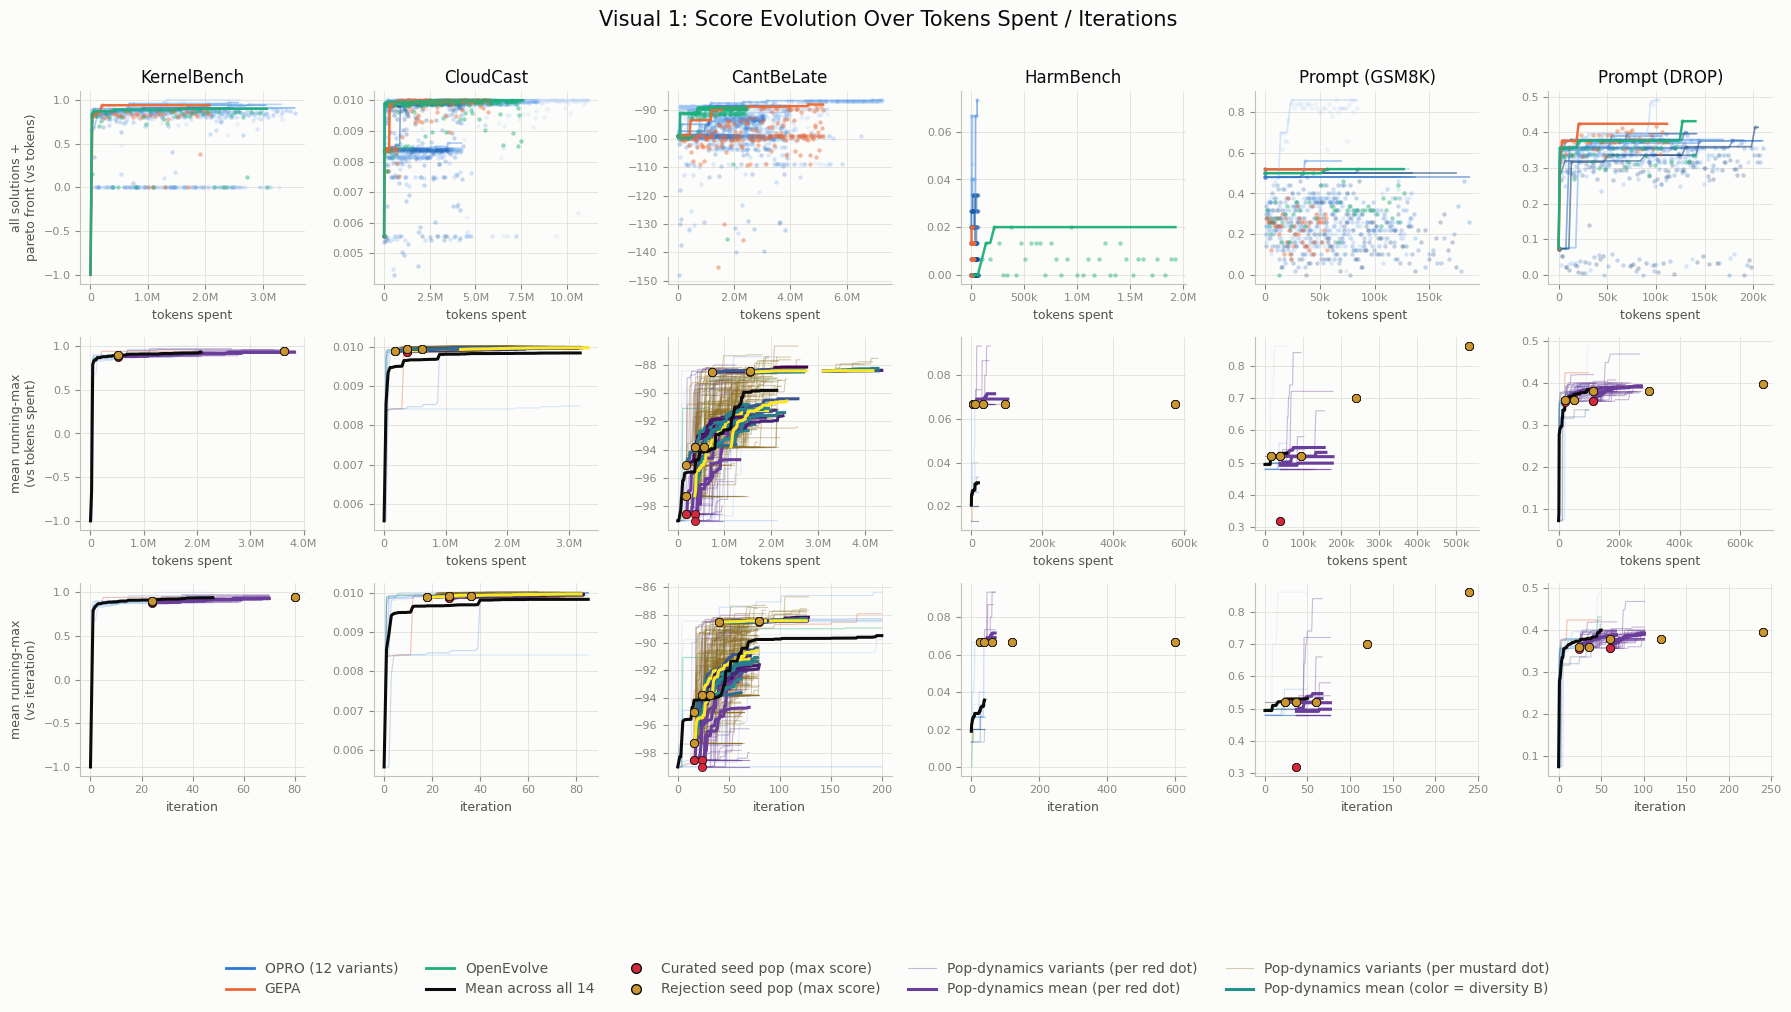

In [9]:
"""Build the 3x6 Visual 1 figure: score evolution over tokens spent / iterations."""

fig, axes = plt.subplots(
    3, 6, figsize=(18, 9), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    optimizers = runs_by_column[column_key]
    task_name = task_for_column(column_key)
    failed_score = TASK_FAILED_SCORE.get(task_name)
    curated_points = curated_points_by_task.get(column_key, [])
    strategy_points = strategy_points_by_task.get(
        column_key, {'tournament': [], 'rejection': []},
    )

    # --- Per-optimizer trajectories: tokens, raw score, running-max score ---
    trajectories = {}
    for optimizer_label, records in optimizers.items():
        tokens = np.array([r['cumulative_tokens_spent'] for r in records], dtype=float)
        scores = np.array([r['score'] for r in records], dtype=float)
        trajectories[optimizer_label] = (tokens, scores, running_max(scores))

    # ================= Row 1: scatter + pareto front (vs tokens) =================
    # Sentinel failed-candidate scores (see TASK_FAILED_SCORE) are dropped
    # from the scatter -- they're a crash marker, not a real score, and
    # left in they'd blow out the y-axis range. The pareto front itself
    # (running_max) is untouched: a sentinel is always far below any real
    # score, so it was never going to be selected as the running max anyway.
    ax = axes[0, col_idx]
    ax.set_facecolor(SURFACE)
    for optimizer_label, (tokens, scores, cummax) in trajectories.items():
        color = color_for(optimizer_label)
        is_opro = optimizer_label.startswith('opro')
        valid = scores != failed_score if failed_score is not None else slice(None)
        ax.scatter(
            tokens[valid], scores[valid], s=10, color=color,
            alpha=0.25 if is_opro else 0.45, linewidths=0,
            zorder=2 if is_opro else 3,
        )
        # Pareto front: plot cummax across EVERY token position (not just
        # the points where a new max was set) -- cummax is already flat
        # between improvements, so this draws the correct step function
        # (flat / jump up / flat...) and, as a side effect, means a run
        # whose first (seed) candidate is never beaten still draws as a
        # flat line spanning its whole duration instead of vanishing.
        # Plotting only the breakpoints (the old `scores >= cummax` mask)
        # rendered nothing at all in that single-breakpoint case -- a
        # 1-point line has no segment to draw, even though the scatter
        # above still shows all of that run's dots.
        ax.plot(
            tokens, cummax,
            color=color, linewidth=1.2 if is_opro else 1.8,
            alpha=0.55 if is_opro else 0.95,
            zorder=2 if is_opro else 4,
        )
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)

    # ================= Row 2: mean running-max vs tokens spent =================
    # Delegated to plot_score_vs_tokens_panel (defined above) -- same
    # drawing code as the standalone per-task figures below, so the two
    # can't drift out of sync.
    diversity_mappable = plot_score_vs_tokens_panel(axes[1, col_idx], column_key)

    # ================= Row 3: mean running-max vs iteration index =================
    # Same running-max quantity as row 2, but x is the iteration/eval count
    # instead of tokens spent -- iteration index already aligns 1:1 across
    # optimizers (no step-interpolation needed), so this isolates "does
    # convergence-per-iteration differ" from row 2's "convergence-per-token".
    min_len = min(len(cummax) for _, _, cummax in trajectories.values())
    iter_grid = np.arange(min_len)

    ax = axes[2, col_idx]
    ax.set_facecolor(SURFACE)
    iter_series = []
    for optimizer_label, (_tokens, _scores, cummax) in trajectories.items():
        color = color_for(optimizer_label)
        is_opro = optimizer_label.startswith('opro')
        clipped = cummax[:min_len]
        iter_series.append(clipped)
        ax.plot(
            iter_grid, clipped, color=color, linewidth=0.8,
            alpha=0.25 if is_opro else 0.4, zorder=2,
        )

    # --- Curated seed-population overlay, same points as row 2, but x is
    # iter_cost = budget * num_trajectories_pooled (see the loader cell
    # above) instead of tokens: a budget-N pool was built from N
    # iterations pooled across ~12 independent trajectories, so the
    # iteration-equivalent cost is N * 12, not N -- mirrors row 2's
    # cost_tokens, which is likewise summed across every pooled
    # trajectory rather than reporting just one. zorder=9 -- see row 2's
    # panel-drawer docstring for why dots sit above the black mean line. ---
    if curated_points:
        ax.scatter(
            [p['iter_cost'] for p in curated_points],
            [p['max_score'] for p in curated_points],
            color=COLOR_CURATED_POP, s=35, marker='o',
            edgecolors=INK_PRIMARY, linewidths=0.5, zorder=9,
        )

    # --- Diversity-rejection seed-population overlay, same points/color as
    # row 2's block above, but x is iter_cost instead of cost_tokens. ---
    if strategy_points['rejection']:
        ax.scatter(
            [p['iter_cost'] for p in strategy_points['rejection']],
            [p['max_score'] for p in strategy_points['rejection']],
            color=COLOR_REJECTION_POP, s=35, marker='o',
            edgecolors=INK_PRIMARY, linewidths=0.5, zorder=9,
        )

    # --- Population-dynamics continuation, same points/mean-line logic as
    # row 2's block above, but x is red_dot.iter_cost + local new-solution
    # index (1-indexed) instead of tokens. pd_max_len (not pd_min_len) +
    # pad_to_length forward-fill shorter variants out to the longest one's
    # length -- same "extend to the longest variant, not the shortest"
    # fix as row 2's pd_grid_end, see plot_score_vs_tokens_panel's
    # docstring above for why that's honest rather than fabricated. ---
    for point in curated_points:
        variants = point['variants']
        if not variants:
            continue
        for variant in variants:
            ax.plot(
                variant['iters'], variant['scores'],
                color=COLOR_POP_DYNAMICS, linewidth=0.8, alpha=0.35, zorder=3,
            )
        pd_max_len = max(len(v['scores']) for v in variants)
        pd_iter_grid = point['iter_cost'] + np.arange(1, pd_max_len + 1)
        pd_iter_series = np.vstack(
            [pad_to_length(v['scores'], pd_max_len) for v in variants],
        )
        pd_iter_mean = np.mean(pd_iter_series, axis=0)
        ax.plot(
            pd_iter_grid, pd_iter_mean, color=COLOR_POP_DYNAMICS,
            linewidth=2.2, zorder=7,
        )

    # --- Population-dynamics continuation, same points/mean-line logic as
    # row 2's mustard block above, but x is mustard_dot.iter_cost + local
    # new-solution index instead of tokens (same MAX-extent fix as above).
    # Mean line color reuses row 2's own diversity_mappable.norm (built by
    # plot_score_vs_tokens_panel above from this same column's rejection
    # points) so a given point's mean line is colored identically in row 2
    # and row 3 -- only reached when diversity_mappable is not None, since
    # that and this loop's `if not variants` check derive from the same
    # underlying strategy_points['rejection'] data. ---
    for point in strategy_points['rejection']:
        variants = point.get('variants', [])
        if not variants:
            continue
        for variant in variants:
            ax.plot(
                variant['iters'], variant['scores'],
                color=COLOR_REJECTION_POP_DYNAMICS, linewidth=0.8, alpha=0.35, zorder=3,
            )
        pd_max_len = max(len(v['scores']) for v in variants)
        pd_iter_grid = point['iter_cost'] + np.arange(1, pd_max_len + 1)
        pd_iter_series = np.vstack(
            [pad_to_length(v['scores'], pd_max_len) for v in variants],
        )
        pd_iter_mean = np.mean(pd_iter_series, axis=0)
        ax.plot(
            pd_iter_grid, pd_iter_mean,
            color=DIVERSITY_CMAP(diversity_mappable.norm(point['b_threshold'])),
            linewidth=2.2, zorder=7,
        )

    # --- Black mean-across-all-14 line, drawn LAST: zorder=8, above every
    # other line in this panel -- same reasoning as row 2's panel drawer. ---
    mean_iter_series = np.mean(np.vstack(iter_series), axis=0)
    ax.plot(iter_grid, mean_iter_series, color=INK_PRIMARY, linewidth=2.2, zorder=8)

    # ================= Shared per-column axis styling =================
    for row_idx in range(3):
        ax = axes[row_idx, col_idx]
        if row_idx in (0, 1):
            ax.xaxis.set_major_formatter(tokens_fmt)
            ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
        else:
            ax.set_xlabel('iteration', color=INK_SECONDARY, fontsize=9)
        ax.tick_params(colors=INK_MUTED, labelsize=8)
        for spine in ax.spines.values():
            spine.set_color(BASELINE)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(color=GRIDLINE, linewidth=0.6)
        ax.set_axisbelow(True)

ROW_LABELS = [
    'all solutions +\npareto front (vs tokens)',
    'mean running-max\n(vs tokens spent)',
    'mean running-max\n(vs iteration)',
]
for row_idx, label in enumerate(ROW_LABELS):
    axes[row_idx, 0].set_ylabel(label, color=INK_SECONDARY, fontsize=9)

# --- One shared legend: 12 OPRO variants collapse to a single swatch,
# per the color-plan (they're a family, not individually legible). Curated
# seed-population dots, the diversity-rejection seed-population dots, and
# both dot families' population-dynamics continuations (rows 2-3 only,
# purple for red dots / olive for mustard dots) each get their own entry.
# Tournament populations are loaded but not plotted, so they intentionally
# have no legend entry here. Reused as-is by the standalone per-task
# figures below (defined once here, after every overlay color exists). ---
legend_handles = [
    plt.Line2D([0], [0], color=BLUE_RAMP[6], lw=2, label='OPRO (12 variants)'),
    plt.Line2D([0], [0], color=COLOR_GEPA, lw=2, label='GEPA'),
    plt.Line2D([0], [0], color=COLOR_OPEN_EVOLVE, lw=2, label='OpenEvolve'),
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=2.2, label='Mean across all 14'),
    plt.Line2D(
        [0], [0], marker='o', color='none', markerfacecolor=COLOR_CURATED_POP,
        markeredgecolor=INK_PRIMARY, markersize=7,
        label='Curated seed pop (max score)',
    ),
    plt.Line2D(
        [0], [0], marker='o', color='none', markerfacecolor=COLOR_REJECTION_POP,
        markeredgecolor=INK_PRIMARY, markersize=7,
        label='Rejection seed pop (max score)',
    ),
    plt.Line2D(
        [0], [0], color=COLOR_POP_DYNAMICS, lw=0.8, alpha=0.35,
        label='Pop-dynamics variants (per red dot)',
    ),
    plt.Line2D(
        [0], [0], color=COLOR_POP_DYNAMICS, lw=2.2,
        label='Pop-dynamics mean (per red dot)',
    ),
    plt.Line2D(
        [0], [0], color=COLOR_REJECTION_POP_DYNAMICS, lw=0.8, alpha=0.35,
        label='Pop-dynamics variants (per mustard dot)',
    ),
    plt.Line2D(
        [0], [0], color=DIVERSITY_CMAP(0.5), lw=2.2,
        label='Pop-dynamics mean (color = diversity B)',
    ),
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=5,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.1),
)

fig.suptitle(
    'Visual 1: Score Evolution Over Tokens Spent / Iterations',
    color=INK_PRIMARY, fontsize=15, y=1.01,
)
fig.tight_layout(rect=(0, 0.1, 1, 1))

FIGS_DIR = '../figs'
os.makedirs(FIGS_DIR, exist_ok=True)
fig.savefig(
    os.path.join(FIGS_DIR, 'visual1_score_evolution.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "visual1_score_evolution.pdf")}')

plt.show()

saved to ../figs/visual1_row2_kernelbench.pdf


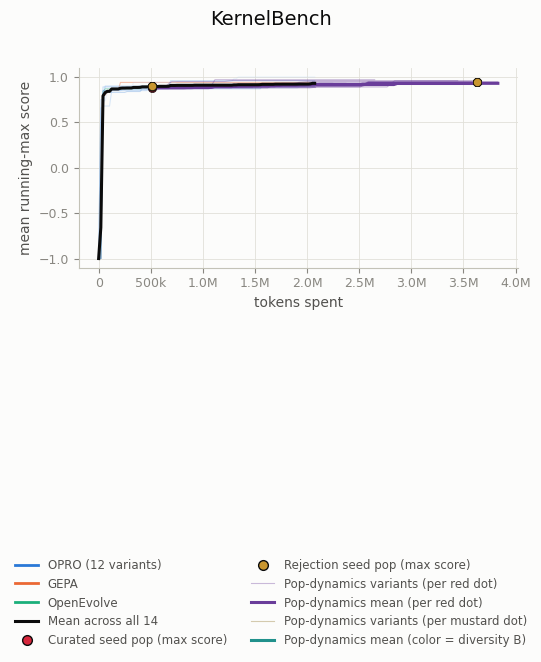

/tmp/ipykernel_101995/1102261640.py:162: RuntimeWarning: Mean of empty slice
  pd_mean = np.nanmean(np.vstack(pd_interpolated), axis=0)


saved to ../figs/visual1_row2_cloudcast.pdf


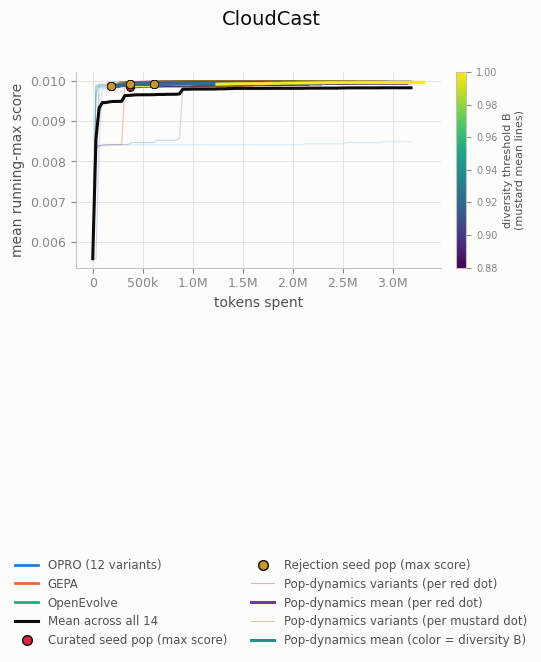

/tmp/ipykernel_101995/1102261640.py:162: RuntimeWarning: Mean of empty slice
  pd_mean = np.nanmean(np.vstack(pd_interpolated), axis=0)


saved to ../figs/visual1_row2_cantbelate.pdf


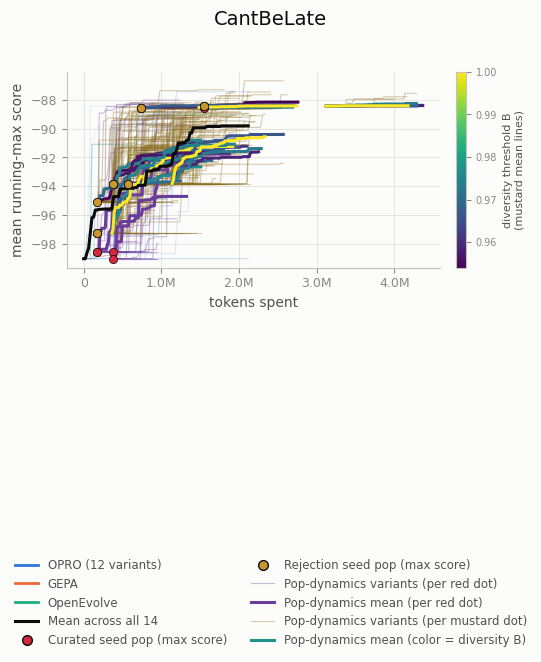

saved to ../figs/visual1_row2_harmbench.pdf


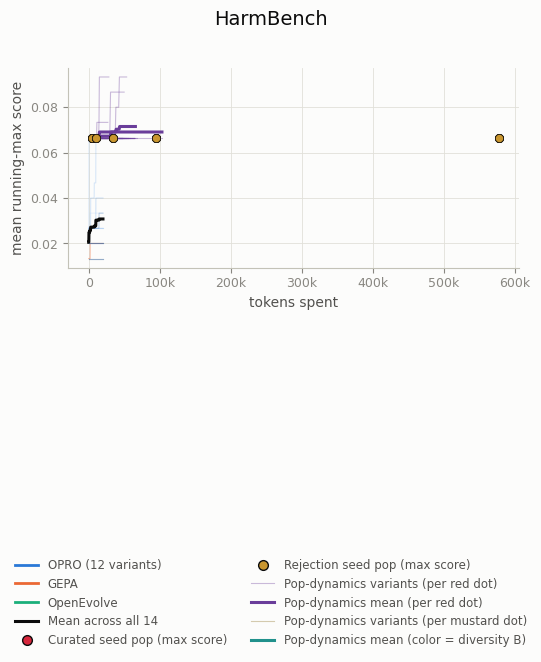

saved to ../figs/visual1_row2_prompt_gsm8k.pdf


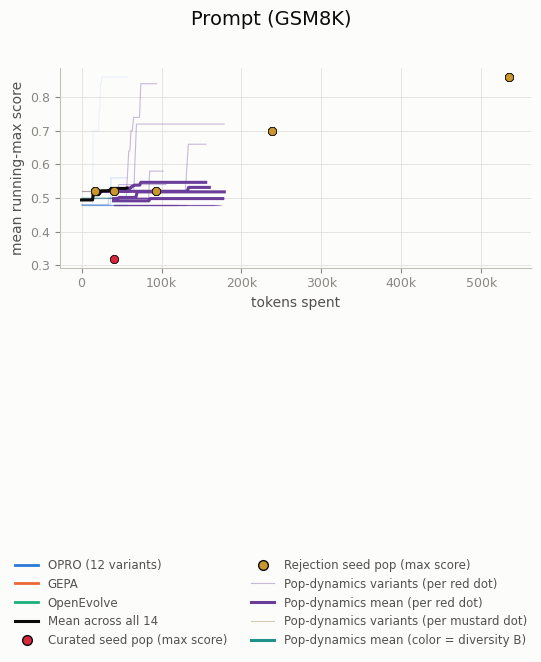

saved to ../figs/visual1_row2_prompt_drop.pdf


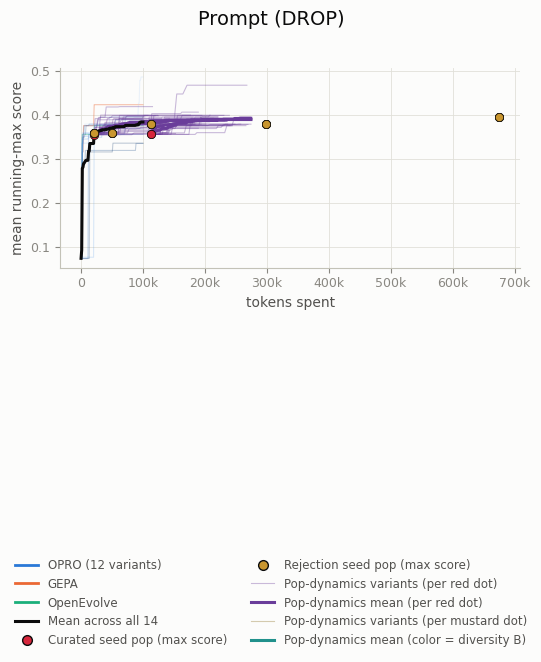

In [10]:
"""Standalone per-task figures: row 2 (mean running-max vs tokens spent) only.

Same panel as the combined figure's row 2, pulled out one task at a time
into its own single-axis figure -- e.g. for a slide/paper figure that
doesn't need the full 3x6 grid. Calls plot_score_vs_tokens_panel directly
(defined above, shared with the combined figure's row 2) so styling/colors/
overlays/z-order/extent behavior can't drift between the two. Reuses the
combined figure's own `legend_handles` list (built in the cell above,
after every overlay color is defined) and `FIGS_DIR` (same save location).

Diversity colorbar: plot_score_vs_tokens_panel returns a ScalarMappable
whenever this column drew any rejection-seed mean lines -- attached here
as a real colorbar (there's room, unlike the cramped 3x6 grid) so the
mustard mean lines' color-by-diversity-threshold-B encoding is actually
readable, not just relatively comparable.
"""

for column_key in COLUMN_ORDER:
    fig, ax = plt.subplots(figsize=(5.5, 4.5), facecolor=SURFACE)
    diversity_mappable = plot_score_vs_tokens_panel(ax, column_key)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=10)
    ax.set_ylabel('mean running-max score', color=INK_SECONDARY, fontsize=10)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)

    if diversity_mappable is not None:
        cbar = fig.colorbar(diversity_mappable, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('diversity threshold B\n(mustard mean lines)', color=INK_SECONDARY, fontsize=8)
        cbar.ax.tick_params(colors=INK_MUTED, labelsize=7)
        cbar.outline.set_edgecolor(BASELINE)

    fig.legend(
        handles=legend_handles, loc='lower center', ncol=2,
        frameon=False, labelcolor=INK_SECONDARY, fontsize=8.5,
        bbox_to_anchor=(0.5, -0.42),
    )
    fig.suptitle(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=14, y=1.02)
    fig.tight_layout(rect=(0, 0.32, 1, 1))

    out_path = os.path.join(FIGS_DIR, f'visual1_row2_{column_key}.pdf')
    fig.savefig(out_path, bbox_inches='tight')
    print(f'saved to {out_path}')
    plt.show()


## Visual 2: semantic diversity evolution

Same 3x6 grid and columns as Visual 1. Diversity metric: windowed average
pairwise cosine **distance** across the last 5 discovered solutions (a
sliding window over chronological history, not the live population) --
code tasks (kernelbench, cloudcast, cantbelate) embedded with
`Qodo/Qodo-Embed-1-1.5B`, text tasks (harmbench, prompt+gsm8k, prompt+drop)
with `all-MiniLM-L6-v2`.

**Row treatment differs from Visual 1 on purpose**: diversity has no
"higher is strictly better, take the running max" framing the way score
does, so all three rows plot the **raw windowed-diversity trajectory**
(no running-max/pareto transform anywhere) -- row 1 is the raw scatter +
raw trajectory line per config, rows 2-3 are the mean of those raw
trajectories vs. tokens spent / iteration index, same as before.

**Embedding cache**: `embedding_cache/*.pkl` already had partial coverage
for some columns (reused here, e.g. `all-MiniLM-L6-v2` for prompt_drop
already had the seed candidate's embedding cached) -- missing texts get
embedded and the cache extended, so a second run of the embedding cell is
instant. The code-task columns run several thousand snippets through a
1.5B-param model with no coverage yet, so the first run of that cell is
the slow step in this notebook -- expect real wall-clock time there.


In [11]:
"""Embedding cache loader + windowed semantic-diversity helper."""

import pickle

import torch
from sentence_transformers import SentenceTransformer

CODE_TASKS = {'kernelbench', 'cloudcast', 'cantbelate'}
CODE_EMBED_MODEL = 'Qodo/Qodo-Embed-1-1.5B'
TEXT_EMBED_MODEL = 'all-MiniLM-L6-v2'
EMBEDDING_CACHE_DIR = '../embedding_cache'
DIVERSITY_WINDOW = 5
EMBED_MAX_SEQ_LENGTH = 4096  # see get_or_build_embeddings docstring


def embed_model_for(column_key: str) -> str:
    """Code embedding model for code tasks, sentence model for text tasks."""
    return CODE_EMBED_MODEL if task_for_column(column_key) in CODE_TASKS else TEXT_EMBED_MODEL


def cache_path_for(column_key: str, model_name: str) -> str:
    filename = f"{column_key}__{model_name.replace('/', '__')}.pkl"
    return os.path.join(EMBEDDING_CACHE_DIR, filename)


def get_or_build_embeddings(
    column_key: str,
    texts: set[str],
    chunk_size: int = 64,
    batch_size: int = 8,
) -> dict[str, np.ndarray]:
    """Load cached embeddings for `texts`, computing + caching what's missing.

    Cache format matches the pre-existing embedding_cache/*.pkl files --
    dict[solution_text, np.ndarray] -- some columns already had partial
    coverage from earlier work, reused here rather than rebuilt from
    scratch.

    Encodes in small chunks, saving the cache to disk after each one.
    Qodo-Embed-1-1.5B's model card calls for flash_attn (not installed in
    this venv), so without it self-attention memory scales quadratically
    with sequence length -- kernelbench solutions run up to ~14k chars
    (~4k tokens), and the original batch_size=32/eager-attention/fp32
    combo was enough to OOM-kill the whole kernel process outright (an
    unclean CUDA OOM, not a catchable Python exception) with zero
    progress saved. fp16 + a capped max_seq_length + a small batch_size
    bound peak memory per batch; sorting missing texts shortest-first
    means a batch never randomly clusters several of the longest
    sequences together (the worst case for a spike); and saving after
    every chunk means a future crash only loses the in-flight chunk
    instead of the whole column.
    """
    model_name = embed_model_for(column_key)
    cache_path = cache_path_for(column_key, model_name)
    os.makedirs(EMBEDDING_CACHE_DIR, exist_ok=True)

    cache: dict[str, np.ndarray] = {}
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            cache = pickle.load(f)

    missing = sorted(texts - cache.keys(), key=len)
    if not missing:
        print(f'[{column_key}] {len(texts)} texts, all cached.')
        return cache

    print(
        f'[{column_key}] embedding {len(missing)} new / {len(texts)} '
        f'total texts with {model_name}...',
    )
    model = SentenceTransformer(
        model_name,
        model_kwargs={'torch_dtype': torch.float16},
    )
    model.max_seq_length = min(model.max_seq_length, EMBED_MAX_SEQ_LENGTH)

    for start in range(0, len(missing), chunk_size):
        chunk = missing[start : start + chunk_size]
        new_embeddings = model.encode(
            chunk, batch_size=batch_size, show_progress_bar=False,
            convert_to_numpy=True,
        )
        cache.update(zip(chunk, new_embeddings, strict=True))
        with open(cache_path, 'wb') as f:
            pickle.dump(cache, f)
        print(
            f'  [{column_key}] {min(start + chunk_size, len(missing))}'
            f'/{len(missing)} embedded and saved',
        )

    del model
    torch.cuda.empty_cache()
    return cache


def windowed_diversity(
    texts: list[str],
    embeddings: dict[str, np.ndarray],
    window: int = DIVERSITY_WINDOW,
) -> np.ndarray:
    """Average pairwise cosine distance across the last `window` solutions.

    Returns an array aligned to texts[window - 1:] -- shorter than `texts`
    itself, since there's no diversity value until `window` solutions
    exist. Duplicate solution text (e.g. open_evolve's islands
    re-proposing the same code -- see the loader markdown above) is left
    in deliberately, same no-dedup stance as Visual 1: a duplicate in the
    window contributes a real 0-distance pair, which is honest signal
    about how much of the window is actually novel.
    """
    vecs = np.stack([embeddings[t] for t in texts])
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    unit = vecs / np.where(norms == 0, 1, norms)

    pair_mask = ~np.eye(window, dtype=bool)
    diversity = np.empty(len(texts) - window + 1)
    for out_idx, i in enumerate(range(window - 1, len(texts))):
        w = unit[i - window + 1 : i + 1]
        sims = w @ w.T
        diversity[out_idx] = 1.0 - sims[pair_mask].mean()
    return diversity


In [12]:
"""Build/load embeddings for every unique solution text per column.

Slow on the first run (code-task columns have thousands of uncached
snippets going through a 1.5B-param model) -- instant after, since results
are cached to embedding_cache/*.pkl.
"""

embeddings_by_column: dict[str, dict[str, np.ndarray]] = {}
for column_key in COLUMN_ORDER:
    all_texts = {
        r['solution']
        for records in runs_by_column[column_key].values()
        for r in records
    }
    embeddings_by_column[column_key] = get_or_build_embeddings(
        column_key, all_texts,
    )


[kernelbench] 498 texts, all cached.
[cloudcast] 1884 texts, all cached.
[cantbelate] 1915 texts, all cached.
[harmbench] 672 texts, all cached.
[prompt_gsm8k] 612 texts, all cached.
[prompt_drop] 697 texts, all cached.


In [13]:
"""Compute windowed diversity trajectories per (column, optimizer)."""

# diversity_by_column[column_key][optimizer_label] = (tokens, diversity)
# tokens/diversity are aligned arrays of length len(records) - (window - 1).
diversity_by_column: dict[str, dict[str, tuple[np.ndarray, np.ndarray]]] = {}

for column_key in COLUMN_ORDER:
    embeddings = embeddings_by_column[column_key]
    per_optimizer = {}
    for optimizer_label, records in runs_by_column[column_key].items():
        texts = [r['solution'] for r in records]
        tokens = np.array([r['cumulative_tokens_spent'] for r in records], dtype=float)
        diversity = windowed_diversity(texts, embeddings)
        aligned_tokens = tokens[DIVERSITY_WINDOW - 1 :]
        per_optimizer[optimizer_label] = (aligned_tokens, diversity)
    diversity_by_column[column_key] = per_optimizer

print('diversity trajectories computed for:')
for column_key, per_optimizer in diversity_by_column.items():
    lengths = [len(d) for _, d in per_optimizer.values()]
    print(f'  {column_key:14s} {len(per_optimizer)} optimizers, trajectory length {min(lengths)}-{max(lengths)}')


diversity trajectories computed for:
  kernelbench    10 optimizers, trajectory length 45-47
  cloudcast      11 optimizers, trajectory length 82-197
  cantbelate     10 optimizers, trajectory length 197-197
  harmbench      14 optimizers, trajectory length 36-47
  prompt_gsm8k   14 optimizers, trajectory length 47-47
  prompt_drop    14 optimizers, trajectory length 47-47


/tmp/ipykernel_101995/4062684787.py:45: RuntimeWarning: Mean of empty slice
  mean_series = np.nanmean(np.vstack(interpolated), axis=0)


saved to ../figs/visual2_diversity_evolution.pdf


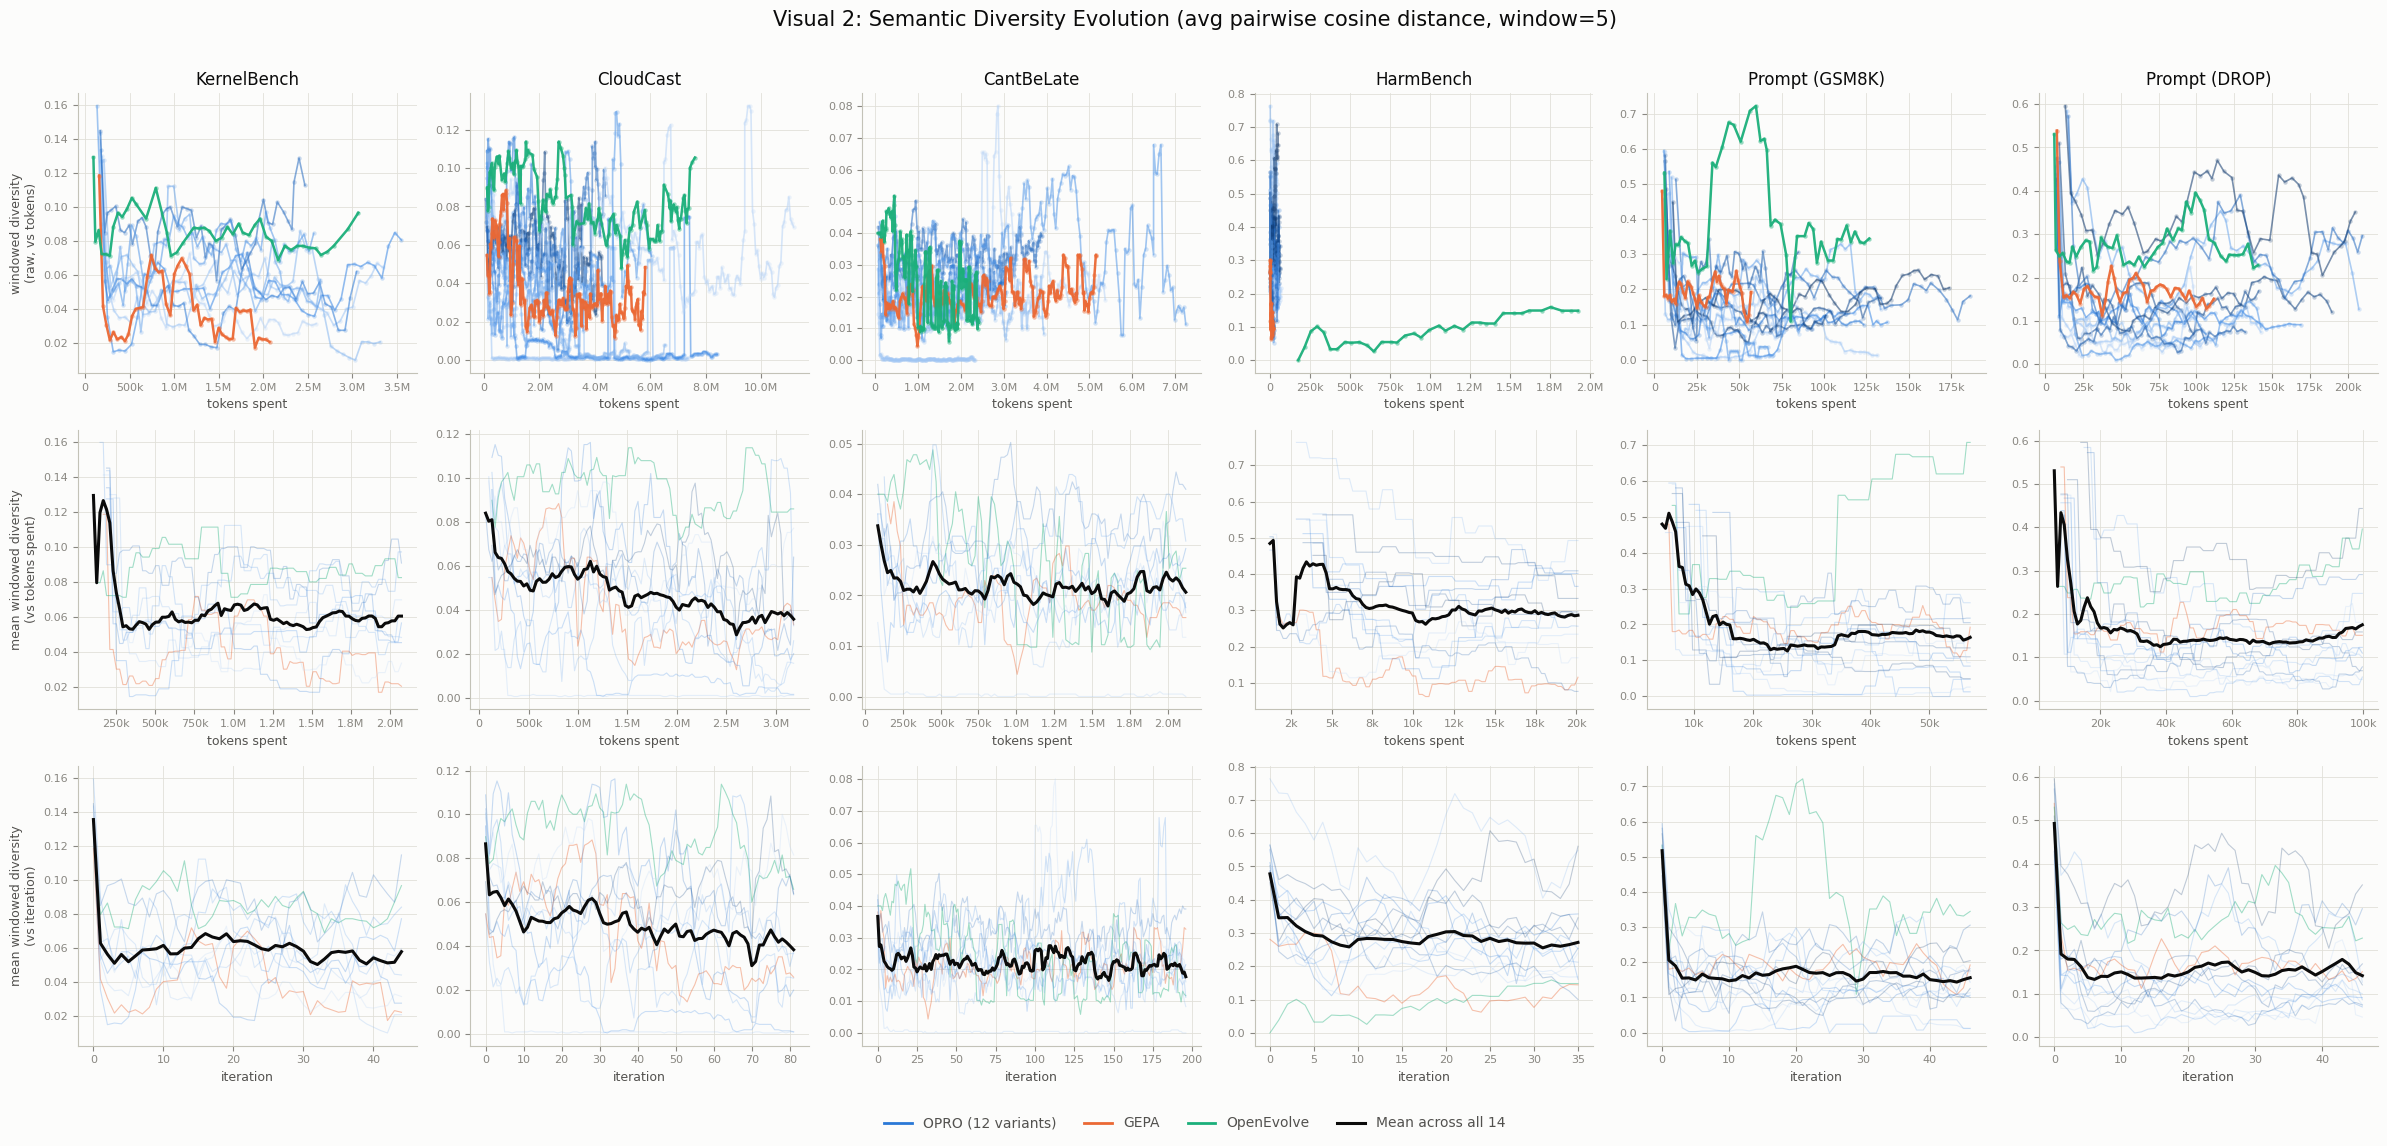

In [14]:
"""Build the 3x6 Visual 2 figure: semantic diversity evolution."""

fig, axes = plt.subplots(
    3, 6, figsize=(24, 11), facecolor=SURFACE, sharex=False, sharey=False,
)

for col_idx, column_key in enumerate(COLUMN_ORDER):
    per_optimizer = diversity_by_column[column_key]

    # ================= Row 1: raw scatter + raw trajectory (vs tokens) =================
    ax = axes[0, col_idx]
    ax.set_facecolor(SURFACE)
    for optimizer_label, (tokens, diversity) in per_optimizer.items():
        color = color_for(optimizer_label)
        is_opro = optimizer_label.startswith('opro')
        ax.scatter(
            tokens, diversity, s=10, color=color,
            alpha=0.25 if is_opro else 0.45, linewidths=0,
            zorder=2 if is_opro else 3,
        )
        ax.plot(
            tokens, diversity, color=color,
            linewidth=1.2 if is_opro else 1.8,
            alpha=0.55 if is_opro else 0.95,
            zorder=2 if is_opro else 4,
        )
    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)

    # ================= Row 2: mean raw diversity vs tokens spent =================
    grid_end = min(t.max() for t, _ in per_optimizer.values())  # safe overlap only
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    ax = axes[1, col_idx]
    ax.set_facecolor(SURFACE)
    interpolated = []
    for optimizer_label, (tokens, diversity) in per_optimizer.items():
        color = color_for(optimizer_label)
        is_opro = optimizer_label.startswith('opro')
        resampled = step_interpolate(tokens, diversity, grid)
        interpolated.append(resampled)
        ax.plot(
            grid, resampled, color=color, linewidth=0.8,
            alpha=0.25 if is_opro else 0.4, zorder=2,
        )
    mean_series = np.nanmean(np.vstack(interpolated), axis=0)
    ax.plot(grid, mean_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    # ================= Row 3: mean raw diversity vs iteration index =================
    min_len = min(len(d) for _, d in per_optimizer.values())
    iter_grid = np.arange(min_len)

    ax = axes[2, col_idx]
    ax.set_facecolor(SURFACE)
    iter_series = []
    for optimizer_label, (_tokens, diversity) in per_optimizer.items():
        color = color_for(optimizer_label)
        is_opro = optimizer_label.startswith('opro')
        clipped = diversity[:min_len]
        iter_series.append(clipped)
        ax.plot(
            iter_grid, clipped, color=color, linewidth=0.8,
            alpha=0.25 if is_opro else 0.4, zorder=2,
        )
    mean_iter_series = np.mean(np.vstack(iter_series), axis=0)
    ax.plot(iter_grid, mean_iter_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    # ================= Shared per-column axis styling =================
    for row_idx in range(3):
        ax = axes[row_idx, col_idx]
        if row_idx in (0, 1):
            ax.xaxis.set_major_formatter(tokens_fmt)
            ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=9)
        else:
            ax.set_xlabel('iteration', color=INK_SECONDARY, fontsize=9)
        ax.tick_params(colors=INK_MUTED, labelsize=8)
        for spine in ax.spines.values():
            spine.set_color(BASELINE)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(color=GRIDLINE, linewidth=0.6)
        ax.set_axisbelow(True)

ROW_LABELS = [
    'windowed diversity\n(raw, vs tokens)',
    'mean windowed diversity\n(vs tokens spent)',
    'mean windowed diversity\n(vs iteration)',
]
for row_idx, label in enumerate(ROW_LABELS):
    axes[row_idx, 0].set_ylabel(label, color=INK_SECONDARY, fontsize=9)

legend_handles = [
    plt.Line2D([0], [0], color=BLUE_RAMP[6], lw=2, label='OPRO (12 variants)'),
    plt.Line2D([0], [0], color=COLOR_GEPA, lw=2, label='GEPA'),
    plt.Line2D([0], [0], color=COLOR_OPEN_EVOLVE, lw=2, label='OpenEvolve'),
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=2.2, label='Mean across all 14'),
]
fig.legend(
    handles=legend_handles, loc='lower center', ncol=4,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.02),
)

fig.suptitle(
    'Visual 2: Semantic Diversity Evolution '
    '(avg pairwise cosine distance, window=5)',
    color=INK_PRIMARY, fontsize=15, y=1.01,
)
fig.tight_layout(rect=(0, 0.02, 1, 1))

FIGS_DIR = '../figs'
os.makedirs(FIGS_DIR, exist_ok=True)
fig.savefig(
    os.path.join(FIGS_DIR, 'visual2_diversity_evolution.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "visual2_diversity_evolution.pdf")}')

plt.show()


# Two Additional Figures


General: I only want to analyze the 12 opro runs (exclude GEPA and OpenEvolve from any means).

1st fig: For each task (cloudcast, cantbelate, harmbench/prompt+drop/prompt+gsm8k w/ (gemma 4B, llama 3.2B, olmo sft, olmo dpo)), I want to visualize the second row of visual 2 above, but instead of printing the mean of all 12 opro runs per task, stratify the mean windowed diversity by the average score over the entire trajectory over three quantiles (meaning top 33% of trajectories w/ high mean scores, middle 33% and bottom 33%) and gradiate the colors. Still have the inidividual trajectories printing in the background w/ a thin line.

2nd fig: for Can't be late and cloud cast, Take every trajectory (no initialization vs. diverisyt rejection sampling initialization) and make a bar plot: Y-axis is the average max-score across all trajectories. The x-axis bins trajectories by how much compute was spent on initialization vs. subsequent rollout (ratio). So for the non-initialized trajectories, the ratio for initialization:rolllout compute is 0, for an initialized trajectory the ratio would be the initialization budget tokens: 2 million - initilaization_budget tokens...and so on. Cap the trajectory results at 2 million tokens.

## Fig A: Semantic Diversity by Score Tercile (OPRO-only)

12 OPRO variants per column, stratified into three groups of 4 by each run's own
mean raw score (crash-sentinel evals excluded, see `TASK_FAILED_SCORE`) across its
full trajectory -- bottom/middle/top tercile -- then plot each tercile's mean
windowed-diversity trajectory (same metric as Visual 2 row 2), with individual runs
drawn thin/faint in the background, colored by their own tercile.

Inference-model layout (confirmed with the user): 5 rows x 4 cols. `cloudcast`/
`cantbelate` (gemma-4B only, no other model variant on disk) occupy just column 0 of
their row; `harmbench`/`prompt_gsm8k`/`prompt_drop` fill all 4 columns, one per
inference model (gemma-4B, Llama-3.2-1B, OLMo-2-0425-1B-SFT, OLMo-2-0425-1B-DPO).
`kernelbench` is intentionally excluded (not in the user's task list for this
figure).

Correction from the first pass: the 3 non-gemma-4B sweeps for harmbench/prompt
(pinned out everywhere else in this notebook by `TASK_INFERENCE_MODEL_FILTER`,
which stays untouched -- this figure alone reaches past it) are actually complete
on disk (51/51 records each, verified) -- an earlier existence check missed them
because their `long_running_solution_bank.json` sits one directory deeper, under a
real `placeholder_path/` subdirectory, than the gemma-4B sweep's flat layout (same
naming-era split already documented in the rejection-continuation loader cell
above, for `population_dynamics/`). `find_bank_path` below checks both layouts.
Embeddings for the 3 new models are cached separately per model (distinct
`embedding_cache/*.pkl` files, all-MiniLM-L6-v2 -- cheap, CPU-only, no GPU needed
even on a cold cache) so they can't collide with each other or with the gemma-4B
cache the rest of the notebook already relies on.

/tmp/ipykernel_101995/1411900768.py:133: RuntimeWarning: Mean of empty slice
  mean_series = np.nanmean(np.vstack(stack), axis=0)


[harmbench] 601 texts, all cached.
[harmbench__llama-3.2-1B] 600 texts, all cached.
[harmbench__olmo-SFT] 590 texts, all cached.
[harmbench__olmo-DPO] 589 texts, all cached.
[prompt_gsm8k] 529 texts, all cached.
[prompt_gsm8k__llama-3.2-1B] 579 texts, all cached.
[prompt_gsm8k__olmo-SFT] 564 texts, all cached.
[prompt_gsm8k__olmo-DPO] 544 texts, all cached.
[prompt_drop] 597 texts, all cached.
[prompt_drop__llama-3.2-1B] 594 texts, all cached.
[prompt_drop__olmo-SFT] 580 texts, all cached.
[prompt_drop__olmo-DPO] 580 texts, all cached.
saved to ../figs/figA_diversity_by_score_tercile.pdf


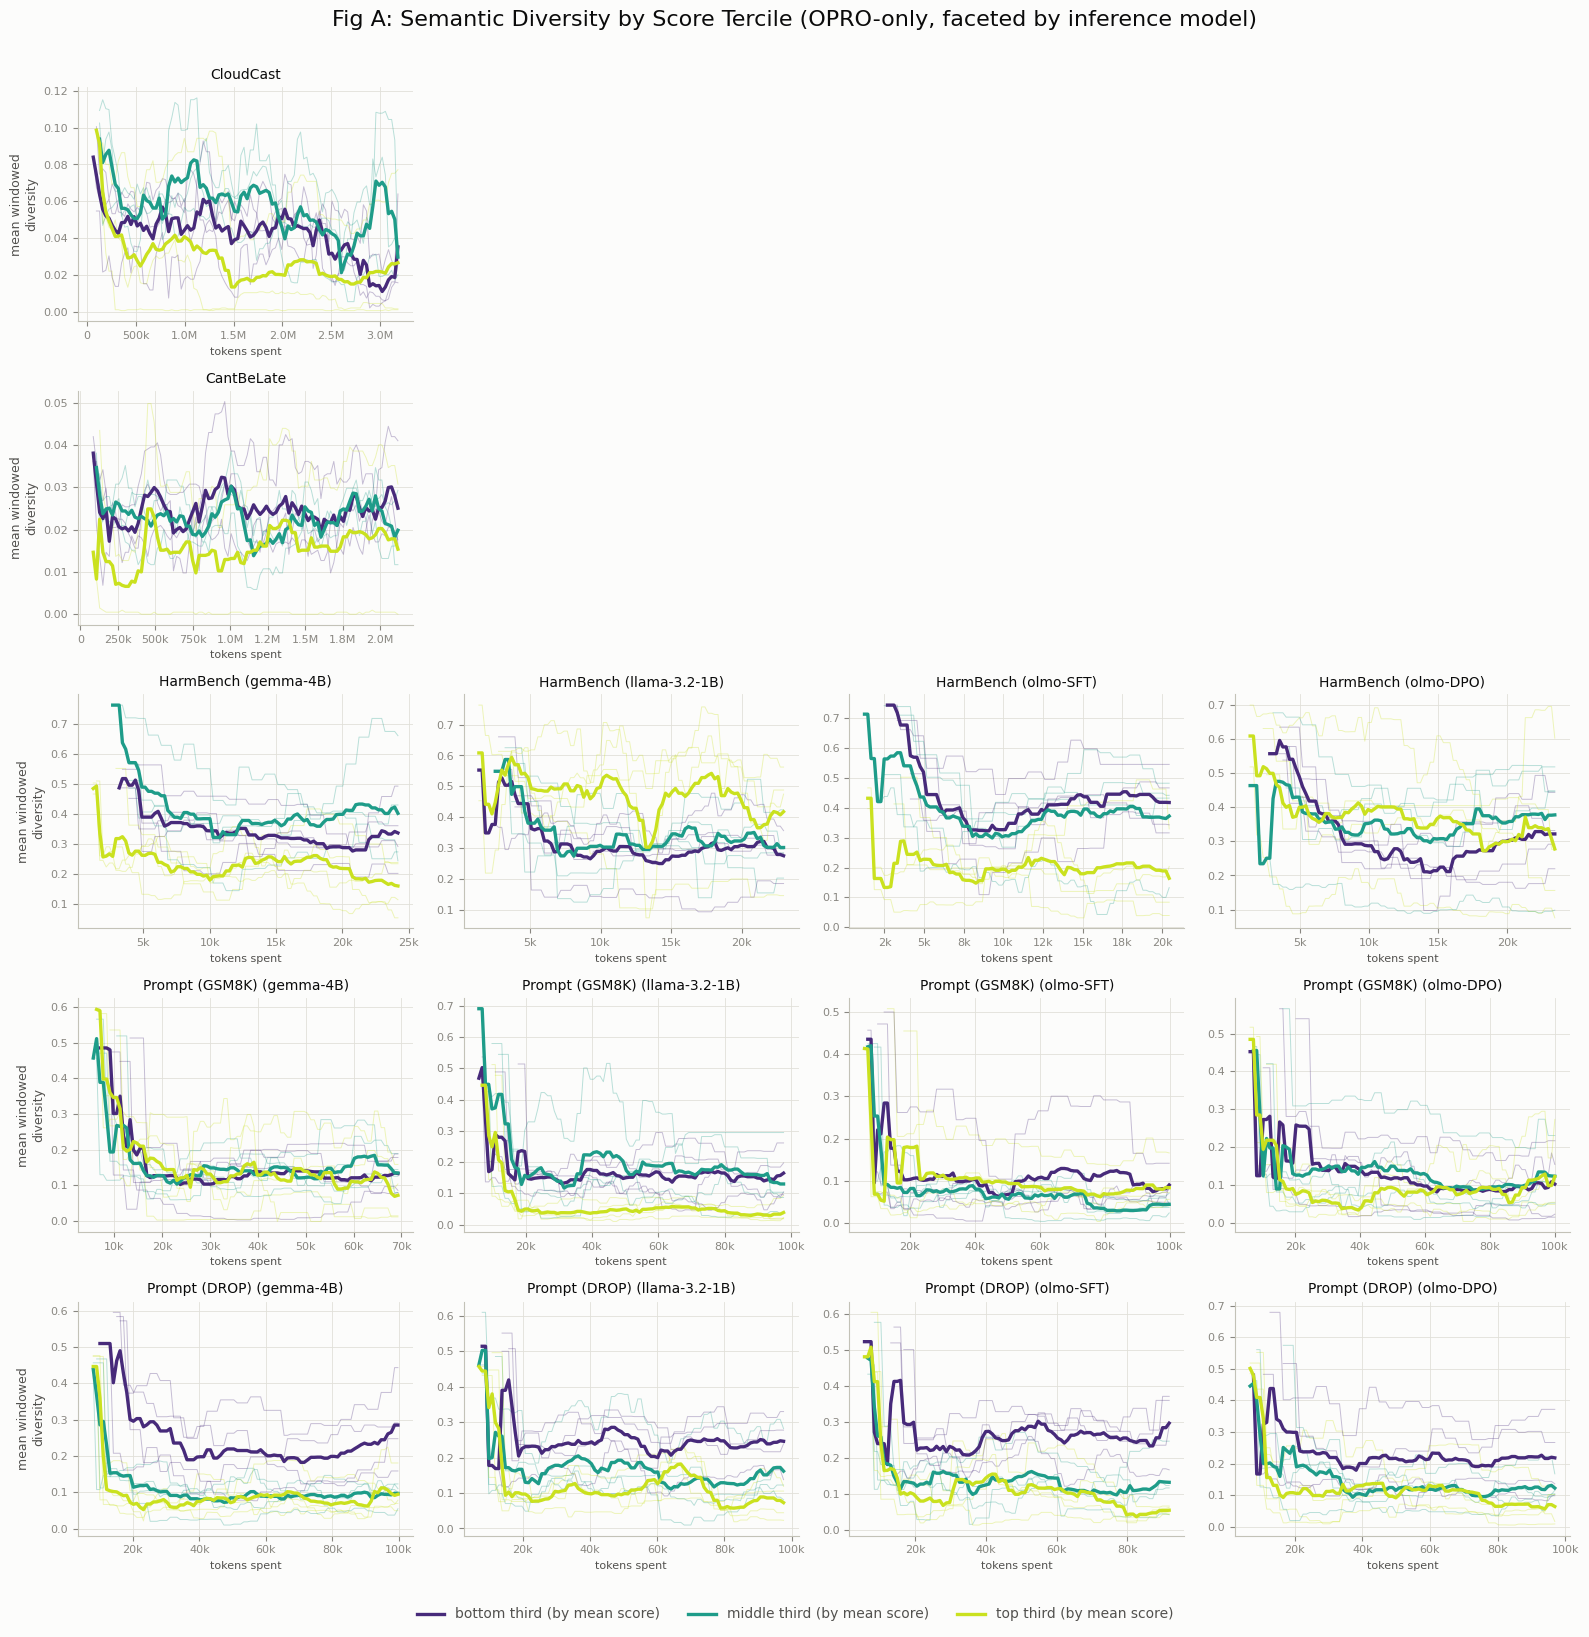

In [15]:
"""Fig A: per-task tercile-stratified semantic diversity (OPRO-only),
faceted by inference model for harmbench/prompt. See the markdown cell above
for the corrected data-availability finding and the layout confirmed with
the user (5 rows x 4 cols, cloudcast/cantbelate only fill column 0).

Score used for ranking is each run's raw per-eval score (not running-max),
since "average score over the entire trajectory" is about how good the run
was on average, not just its best find -- crash-sentinel evals
(TASK_FAILED_SCORE) are excluded from that average.
"""

FIG_A_MODEL_TOKENS = {
    'gemma-4B': 'googlegemma-4-E4B-it',
    'llama-3.2-1B': 'meta-llamaLlama-32-1B-Instruct',
    'olmo-SFT': 'allenaiOLMo-2-0425-1B-SFT',
    'olmo-DPO': 'allenaiOLMo-2-0425-1B-DPO',
}
FIG_A_MODEL_ORDER = ['gemma-4B', 'llama-3.2-1B', 'olmo-SFT', 'olmo-DPO']

TERCILE_CMAP = plt.get_cmap('viridis')
TERCILE_LABELS = ['bottom third', 'middle third', 'top third']
TERCILE_COLOR = {
    'bottom third': TERCILE_CMAP(0.12),
    'middle third': TERCILE_CMAP(0.55),
    'top third': TERCILE_CMAP(0.92),
}


def find_bank_path(run_dir: str) -> str | None:
    """long_running_solution_bank.json for a run dir, whichever layout era
    it's from: flat at the run dir's root (older gemma-4B sweep) or nested
    one level under a real placeholder_path/ subdirectory (newer sweep) --
    see the markdown cell above.
    """
    direct = os.path.join(run_dir, 'long_running_solution_bank.json')
    if os.path.exists(direct):
        return direct
    nested = glob.glob(os.path.join(run_dir, '*', 'long_running_solution_bank.json'))
    return nested[0] if nested else None


def load_opro_runs_for_model(task_token: str, model_token: str) -> dict[str, dict[str, list[dict]]]:
    """{column_key: {optimizer_label: records}}, OPRO only, for one
    (task_token, model_token) -- column_key resolves 'prompt' into
    'prompt_gsm8k'/'prompt_drop', same split as parse_run_dir.
    """
    by_column: dict[str, dict[str, list[dict]]] = {}
    run_dirs = glob.glob(os.path.join(EXPERIMENT_DIR, f'opro_*_{task_token}_{model_token}_*/'))
    max_len = TASK_NUM_ITER[task_token] + 1
    for run_dir in run_dirs:
        dirname = os.path.basename(run_dir.rstrip('/'))
        _optimizer_name, _task_name, column_key, mutator, sampling_strategy = parse_run_dir(dirname)
        bank_path = find_bank_path(run_dir.rstrip('/'))
        if bank_path is None:
            continue
        records = load_bank(bank_path)
        if len(records) > max_len:
            records = records[:max_len]
        optimizer_label = f'opro_{mutator}_{sampling_strategy}'
        by_column.setdefault(column_key, {})[optimizer_label] = records
    return by_column


def diversity_trajectories_for(
    cache_key: str, by_optimizer: dict[str, list[dict]],
) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    """opro-only per_optimizer -> (aligned_tokens, windowed_diversity),
    embedding + caching via get_or_build_embeddings (cell above) under
    `cache_key` -- distinct per inference model so the 4 models' embeddings
    don't collide in embedding_cache/, and gemma-4B's key matches the
    primary column_key so it can reuse whatever cell 15 above already
    cached for it.
    """
    all_texts = {r['solution'] for records in by_optimizer.values() for r in records}
    embeddings = get_or_build_embeddings(cache_key, all_texts)
    per_optimizer = {}
    for label, records in by_optimizer.items():
        texts = [r['solution'] for r in records]
        tokens = np.array([r['cumulative_tokens_spent'] for r in records], dtype=float)
        diversity = windowed_diversity(texts, embeddings)
        per_optimizer[label] = (tokens[DIVERSITY_WINDOW - 1:], diversity)
    return per_optimizer


def mean_scores_for(by_optimizer: dict[str, list[dict]], task_name: str) -> dict[str, float]:
    """optimizer_label -> mean raw score, crash-sentinel evals excluded (see
    TASK_FAILED_SCORE) so a task's crash rate doesn't dominate the ranking
    used for tercile stratification.
    """
    failed_score = TASK_FAILED_SCORE.get(task_name)
    means = {}
    for label, records in by_optimizer.items():
        scores = np.array([r['score'] for r in records], dtype=float)
        valid = scores != failed_score if failed_score is not None else np.ones_like(scores, dtype=bool)
        means[label] = scores[valid].mean() if valid.any() else float('nan')
    return means


def tercile_assignment(mean_scores: dict[str, float]) -> dict[str, str]:
    """label -> TERCILE_LABELS entry, by ascending mean score (4/4/4 for 12 labels)."""
    ranked = sorted(mean_scores, key=mean_scores.get)
    groups = np.array_split(ranked, len(TERCILE_LABELS))
    return {
        label: tercile
        for tercile, group in zip(TERCILE_LABELS, groups)
        for label in group
    }


def draw_tercile_panel(
    ax: plt.Axes,
    per_optimizer: dict[str, tuple[np.ndarray, np.ndarray]],
    mean_scores: dict[str, float],
) -> None:
    """One panel: thin per-run lines colored by tercile + bold tercile-mean lines."""
    ax.set_facecolor(SURFACE)
    tercile_of = tercile_assignment(mean_scores)

    grid_end = min(tokens.max() for tokens, _ in per_optimizer.values())  # safe overlap only
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    resampled_by_tercile: dict[str, list[np.ndarray]] = {t: [] for t in TERCILE_LABELS}
    for label, (tokens, diversity) in per_optimizer.items():
        tercile = tercile_of[label]
        resampled = step_interpolate(tokens, diversity, grid)
        resampled_by_tercile[tercile].append(resampled)
        ax.plot(grid, resampled, color=TERCILE_COLOR[tercile], linewidth=0.7, alpha=0.3, zorder=2)

    for tercile in TERCILE_LABELS:
        stack = resampled_by_tercile[tercile]
        if not stack:
            continue
        mean_series = np.nanmean(np.vstack(stack), axis=0)
        ax.plot(grid, mean_series, color=TERCILE_COLOR[tercile], linewidth=2.4, zorder=5)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)


# --- Row specs: (row_label, column_key, task_name, is_multi_model) --
# cloudcast/cantbelate reuse the existing globals (runs_by_column /
# diversity_by_column from cells 2-16 above, gemma-4B only, their only
# variant on disk); harmbench/prompt_gsm8k/prompt_drop are freshly loaded
# per inference model via load_opro_runs_for_model above.
FIG_A_ROWS = [
    ('CloudCast', 'cloudcast', 'cloudcast', False),
    ('CantBeLate', 'cantbelate', 'cantbelate', False),
    ('HarmBench', 'harmbench', 'harmbench', True),
    ('Prompt (GSM8K)', 'prompt_gsm8k', 'prompt', True),
    ('Prompt (DROP)', 'prompt_drop', 'prompt', True),
]

# Pre-load each multi-model row's data once per (task_name, model) pair --
# prompt_gsm8k/prompt_drop share the same load_opro_runs_for_model call
# since parse_run_dir splits both column_keys out of the same
# task_token='prompt' run dirs, so this only issues 2 x 4 = 8 glob passes,
# not one per row.
multimodel_runs: dict[tuple[str, str], dict[str, dict]] = {}
for _row_label, _column_key, task_name, is_multi in FIG_A_ROWS:
    if not is_multi or task_name in {t for t, _ in multimodel_runs}:
        continue
    for model_label, model_token in FIG_A_MODEL_TOKENS.items():
        multimodel_runs[(task_name, model_label)] = load_opro_runs_for_model(task_name, model_token)

fig, axes = plt.subplots(5, 4, figsize=(16, 16), facecolor=SURFACE, sharex=False, sharey=False)

for row_idx, (row_label, column_key, task_name, is_multi) in enumerate(FIG_A_ROWS):
    for col_idx in range(4):
        ax = axes[row_idx, col_idx]

        if not is_multi:
            if col_idx > 0:
                ax.axis('off')
                continue
            by_optimizer = {
                label: records for label, records in runs_by_column[column_key].items()
                if label.startswith('opro')
            }
            per_optimizer = {
                label: traj for label, traj in diversity_by_column[column_key].items()
                if label.startswith('opro')
            }
            title = row_label
        else:
            model_label = FIG_A_MODEL_ORDER[col_idx]
            by_optimizer = multimodel_runs[(task_name, model_label)].get(column_key, {})
            if not by_optimizer:
                ax.axis('off')
                continue
            cache_key = column_key if model_label == 'gemma-4B' else f'{column_key}__{model_label}'
            per_optimizer = diversity_trajectories_for(cache_key, by_optimizer)
            title = f'{row_label} ({model_label})'

        mean_scores = mean_scores_for(by_optimizer, task_name)
        draw_tercile_panel(ax, per_optimizer, mean_scores)
        ax.set_title(title, color=INK_PRIMARY, fontsize=10)
        ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=8)

    axes[row_idx, 0].set_ylabel('mean windowed\ndiversity', color=INK_SECONDARY, fontsize=9)

fig_a_legend_handles = [
    plt.Line2D([0], [0], color=TERCILE_COLOR[t], lw=2.4, label=f'{t} (by mean score)')
    for t in TERCILE_LABELS
]
fig.legend(
    handles=fig_a_legend_handles, loc='lower center', ncol=3,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.01),
)

fig.suptitle(
    'Fig A: Semantic Diversity by Score Tercile (OPRO-only, faceted by inference model)',
    color=INK_PRIMARY, fontsize=16, y=1.005,
)
fig.tight_layout(rect=(0, 0.02, 1, 1))

fig.savefig(
    os.path.join(FIGS_DIR, 'figA_diversity_by_score_tercile.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "figA_diversity_by_score_tercile.pdf")}')

plt.show()

## Fig B: Initialization vs Rollout Compute Trade-off (OPRO-only)

CantBeLate and CloudCast only -- the only two tasks with diversity-rejection-
sampling seed populations that actually have `population_dynamics` continuation
runs on disk (see the rejection-continuation loader cell above). Bars: one
'no init' bin (ratio 0) plus one bin per distinct seed-population max score that
has continuation data -- ties across budgets collapse into the same bin
(confirmed with the user against Visual 1's mustard dots: 6 bins for CantBeLate,
3 for CloudCast). Bar height = mean, across every individual trajectory pooled
into that bin, of its own running-max score truncated at 2M cumulative tokens.

saved to ../figs/figB_compute_ratio_bars.pdf


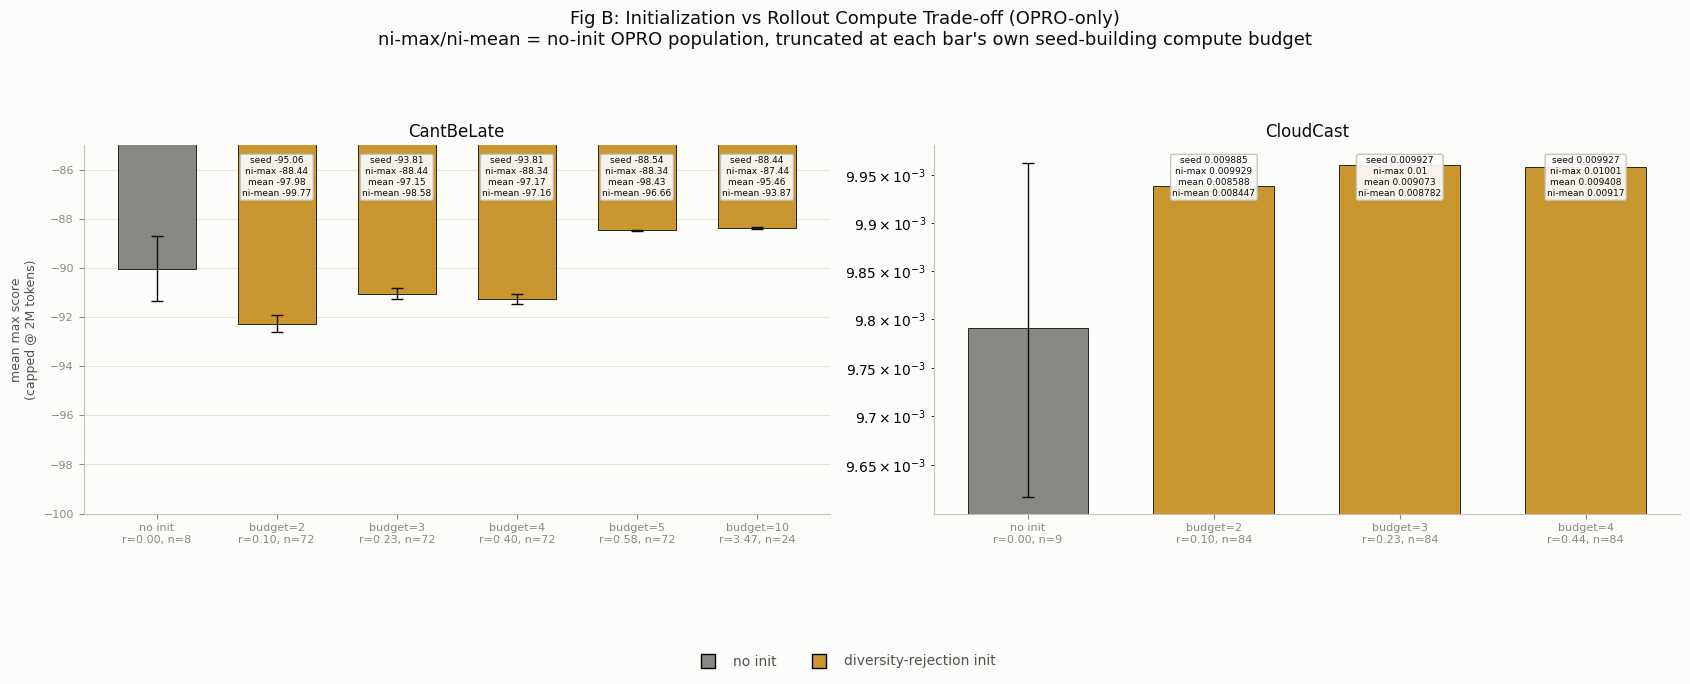

In [16]:
"""Fig B: CantBeLate/CloudCast -- mean capped max-score vs init:rollout
compute ratio (OPRO-only, no-init vs diversity-rejection-sampling init).

Bins (confirmed with the user, binned by budget_iterations rather than seed
max_score): one 'no init' bin (ratio 0, the plain general_rollout OPRO
runs) plus one bin per DISTINCT `budget` -- the raw iteration count used to
build that task's diversity-rejection seed pool. compute_cost_tokens (and
so Visual 1's row-2 x position) depends only on (task_token, budget,
dataset), so every pop_key/B-threshold built from the same budget shares
one x position and its mustard dots visibly overlap there on Visual 1 --
that overlap, not a max_score coincidence, is the actual "one bin" signal.
Binning by max_score instead (the previous approach) got this backwards in
both directions: it split same-budget dots that happened to reach
different max_score into separate bins (e.g. cantbelate's budget=2
pop_keys split across max_score -97.253/-95.058 despite sharing one x
position), and it merged different-budget dots that happened to tie on
max_score into one bin (e.g. cantbelate's budget=3/budget=4 pools both
topped out at max_score=-93.814 despite being two distinct x positions,
379854 vs 566684 tokens). Restricted, as before, to budgets with >=1
population_dynamics continuation on disk (strategy_points_by_task[col]
['rejection'], filtered to point['variants']). Verified count: 5 rejection
bins (budgets 2/3/4/5/10) + no-init = 6 total for cantbelate; 3 rejection
bins (budgets 2/3/4) + no-init = 4 total for cloudcast.

Each bin pools every individual trajectory belonging to it (no-init: the
plain opro runs; a rejection bin: every population_dynamics continuation
variant, across every pop_key built at that bin's budget). y = mean,
across a bin's pooled trajectories, of that trajectory's own running-max
score truncated at TOKEN_CAP cumulative tokens (a variant's own 'tokens'
array from load_pop_dynamics_trajectory is already cost_offset + own
tokens, i.e. absolute total spend, so no extra addition is needed here).
x = the bin's ratio, using the MEAN cost_tokens across the pop_keys pooled
into it purely for bar placement (all pop_keys at one budget already share
the same cost_tokens, so this mean is exact, not an approximation; each
trajectory is still capped against its OWN point's cost_tokens, not the
bin's mean).

Only cantbelate/cloudcast get a panel: they're the only two tasks with any
rejection-seed population_dynamics continuations on disk.

Error bars = standard error of the mean across each bin's pooled
trajectories (0 for a bin with a single trajectory). CantBeLate's
y-axis is zoomed to [-100, -85] (confirmed with the user) -- wide enough
to keep all 6 bars' true heights visible (lowest mean is -92.3, the
budget=2 rejection bin).

Per-bar annotations (confirmed with the user, every initialized bar except
'no init'): seed max (the best max_score among that bin's pooled seed
populations -- all built at the same budget, so they typically agree
already), mean (see below -- NOT the bar's own height, despite the label;
confirmed with the user this replaces what used to be the bar-height
value here), and two COMPUTE-CONTROLLED no-init reference numbers, ni-max
and ni-mean -- see noinit_stats_at below, these are now TWO DIFFERENT KINDS
of quantity, not the same "no-init OPRO trajectories' running-max score"
definition applied twice. Both are truncated at the SAME token budget the
seed population itself cost to build (bar['compute_budget'], the bin's
mean cost_tokens -- same quantity already used for the bar's
x-position/ratio), answering "what would a non-initialized run look like
by the time this much compute went into building the seed pool instead",
not "what does no-init eventually reach at the full 2M cap" (that's the
separate 'no init' bar). Different bars in the same panel get different
no-init reference numbers since each has its own seed cost.

'mean' annotation (confirmed with the user, replacing the old "bar's own
height" definition): quality of the STARTING seed populations themselves,
not the downstream rollout outcome -- deliberately upstream of what the
bar height shows. Per seed population (point) pooled into this bin,
average its own solutions' scores over that point's OWN actual size
(point['seed_score_sum'] / point['num_seeds'], see the loader cell above
-- num_seeds runs 5-10 depending on task/budget). Then take a plain,
equal-weight mean of those per-population averages across every point in
the bin (one number per point, NOT per point's pooled variants -- unlike
the bar height/'values', this doesn't touch population_dynamics
continuation data at all, only each point's own static seed file).

Originally divided by the fixed OPRO pruning cap (MAX_POPULATION_SIZE=20,
generate_experiment_args.py) instead of each population's own actual
size, to penalize thinner-than-full seed pools -- reverted (confirmed
with the user) once that made 'mean'/'ni-mean' impossible to compare:
seed pools are always thin (5-10 of 20 slots) while no-init trajectories'
own active populations are essentially always FULL (~20-21 of 20) by any
budget large enough to matter, so the shared fixed-20 denominator
deflated the two by very different, budget-independent amounts rather
than normalizing them onto the same footing. Dividing each by its own
actual size removes that asymmetry -- both are now plain, ordinary
averages again.

'ni-mean' (confirmed with the user, same treatment as 'mean', NOT the same
definition as 'ni-max'): each no-init OPRO trajectory's own ACTIVE
POPULATION -- reconstructed as of the bar's token budget from that
record's own 'active_population' field (the exact live-population ids
OPRO itself tracked at runtime, see active_population_avg_at below) --
averaged over its OWN actual size (however many of those ids resolve to a
real score, typically ~20-21), then averaged again across every no-init
trajectory that has one. 'ni-max' is intentionally left as the OLD
trajectory-outcome definition (max of capped_running_max, unchanged --
confirmed with the user).
"""

TOKEN_CAP = 2_000_000
COLOR_NOINIT = INK_MUTED


def capped_running_max(tokens: np.ndarray, scores: np.ndarray, cap: float) -> float | None:
    """Running-max score as of the last eval at/before `cap` tokens, or None
    if this trajectory has no eval within budget at all.
    """
    within = tokens <= cap
    if not within.any():
        return None
    return running_max(scores)[within][-1]


def noinit_raw_trajectories(column_key: str) -> list[tuple[np.ndarray, np.ndarray]]:
    """(tokens, scores) per no-init OPRO trajectory, uncapped -- callers cap
    at whatever token budget they need: TOKEN_CAP for the 'no init' bar's
    own height, or a specific bin's own seed cost for the compute-controlled
    reference annotations (see noinit_stats_at below).
    """
    trajectories = []
    for label, records in runs_by_column[column_key].items():
        if not label.startswith('opro'):
            continue
        tokens = np.array([r['cumulative_tokens_spent'] for r in records], dtype=float)
        scores = np.array([r['score'] for r in records], dtype=float)
        trajectories.append((tokens, scores))
    return trajectories


def noinit_raw_records(column_key: str) -> list[list[dict]]:
    """Full per-record dicts (score, cumulative_tokens_spent,
    active_population, ...), per no-init OPRO trajectory, chronological --
    same trajectories as noinit_raw_trajectories above, but keeping every
    field rather than just tokens/score, since active_population_avg_at
    below needs 'active_population' too.
    """
    return [
        records for label, records in runs_by_column[column_key].items()
        if label.startswith('opro')
    ]


def active_population_avg_at(
    records: list[dict], token_budget: float, failed_score: float | None,
) -> float | None:
    """One no-init trajectory's own OPRO-pruned active population, as of
    the last record at/before `token_budget` cumulative tokens (same
    "last eval within budget" cutoff as capped_running_max above) --
    confirmed with the user, same treatment as the 'mean' annotation.

    Reads the active population directly off that record's own
    'active_population' field -- the exact set of iteration ids OPRO
    itself still had live at that point, logged in real time by
    SolutionBank.add_solution_score_pair (llm_optimizer/optimizers/
    opro.py) -- rather than re-simulating prune_population's
    'lowest_scoring' rule from scratch. Relies on `records` being gap-free
    1-indexed (never_prune_bank's keys only ever grow by +1, see
    add_solution_score_pair's `next_iter = max(bank, default=0) + 1`, and
    it's never deleted from -- only the separate, live-pruned self.bank
    loses entries), so record i's own iteration id is exactly i+1 and a
    plain id_to_score dict built from `records`' own order is enough to
    resolve every id an active_population list can reference (all of
    which are <= the owning record's own id, since a candidate can only
    be "active" once it's already been added).

    `failed_score` (TASK_FAILED_SCORE.get(task_name), see the caller)
    entries are dropped entirely, not just left out of the average's
    numerator -- confirmed with the user. A crashed-candidate sentinel
    (e.g. cantbelate's -100_000.0) can genuinely sit inside
    'active_population' if OPRO's own pruning hadn't evicted it yet, and
    it isn't a real score any more than it is on row 1's scatter (which
    drops it the same way) -- so it doesn't occupy a counted slot here
    either, unlike a merely-thin population early in a run.

    Averaged over however many (non-sentinel) scores are actually in that
    list -- an ordinary average over this trajectory's own current active-
    population size, same as the 'mean' annotation now divides by each
    seed population's own num_seeds rather than a fixed cap. None if no
    record falls within budget, or that record's own active_population
    has no surviving (non-sentinel) entries.
    """
    within = [r for r in records if r['cumulative_tokens_spent'] <= token_budget]
    if not within:
        return None
    active_ids = within[-1].get('active_population', [])
    if not active_ids:
        return None
    id_to_score = {i + 1: r['score'] for i, r in enumerate(records)}
    scores = [
        id_to_score[i] for i in active_ids
        if i in id_to_score and id_to_score[i] != failed_score
    ]
    if not scores:
        return None
    return float(np.mean(scores))


def noinit_bin_values(column_key: str) -> list[float]:
    values = []
    for tokens, scores in noinit_raw_trajectories(column_key):
        v = capped_running_max(tokens, scores, TOKEN_CAP)
        if v is not None:
            values.append(v)
    return values


def noinit_stats_at(column_key: str, token_budget: float) -> tuple[float | None, float | None]:
    """(max, mean) compute-controlled no-init reference for one bar's
    annotation (see the cell docstring above) -- the two halves are
    DIFFERENT quantities, not the same trajectory-outcome value twice
    (confirmed with the user):

    max ('ni-max', unchanged): best, across no-init trajectories, of each
    trajectory's own capped_running_max running-max score truncated at
    `token_budget` -- a trajectory-OUTCOME quantity, sentinel-safe as-is
    since a TASK_FAILED_SCORE sentinel is always far below any real score
    and so can never win a max (see capped_running_max/running_max).

    mean ('ni-mean', same treatment as the 'mean' annotation): each
    no-init trajectory's own reconstructed ACTIVE POPULATION as of
    `token_budget` (active_population_avg_at above -- sentinel-filtered
    and averaged over its own actual size there), averaged again across
    every no-init trajectory that has one -- a population-QUALITY
    quantity, upstream of trajectory outcome, mirroring how 'mean' looks
    at seed populations instead of rollout results.
    """
    failed_score = TASK_FAILED_SCORE.get(task_for_column(column_key))
    max_values = [
        v for tokens, scores in noinit_raw_trajectories(column_key)
        if (v := capped_running_max(tokens, scores, token_budget)) is not None
    ]
    mean_values = [
        v for records in noinit_raw_records(column_key)
        if (v := active_population_avg_at(records, token_budget, failed_score)) is not None
    ]
    noinit_max = max(max_values) if max_values else None
    noinit_mean = float(np.mean(mean_values)) if mean_values else None
    return noinit_max, noinit_mean


def rejection_score_bins(column_key: str) -> dict[int, dict]:
    """budget (iteration count used to build the seed pool) ->
    {'cost_tokens': [...], 'values': [...], 'max_scores': [...],
    'seed_avgs': [...]}.

    Keyed by budget, not by seed max_score -- see the cell docstring above
    for why: every pop_key/B-threshold built at the same budget shares one
    x position (cost_tokens is a pure function of budget), so that shared
    x position -- not whichever max_score a given B-threshold's pool
    happened to land on -- is the actual "one bin" signal.
    """
    bins: dict[int, dict] = {}
    for point in strategy_points_by_task[column_key]['rejection']:
        variants = point.get('variants', [])
        if not variants:
            continue
        key = point['budget']
        b = bins.setdefault(
            key,
            {'cost_tokens': [], 'values': [], 'max_scores': [], 'seed_avgs': []},
        )
        b['cost_tokens'].append(point['cost_tokens'])
        b['max_scores'].append(point['max_score'])
        # this point's own seed-population average -- its own actual
        # num_seeds, not a fixed cap, see the cell docstring above
        b['seed_avgs'].append(point['seed_score_sum'] / point['num_seeds'])
        for variant in variants:
            v = capped_running_max(variant['tokens'], variant['scores'], TOKEN_CAP)
            if v is not None:
                b['values'].append(v)
    return bins


def sem(values: list[float]) -> float:
    """Standard error of the mean -- 0 for a single-trajectory bin (nothing
    to estimate spread from) rather than NaN.
    """
    if len(values) < 2:
        return 0.0
    return float(np.std(values, ddof=1) / np.sqrt(len(values)))


def compute_ratio_bars(column_key: str) -> list[dict]:
    bars = []
    noinit_values = noinit_bin_values(column_key)
    if noinit_values:
        bars.append({
            'tick_label': 'no init',
            'ratio': 0.0,
            'mean_score': float(np.mean(noinit_values)),
            'sem': sem(noinit_values),
            'n': len(noinit_values),
        })
    for budget_key, b in sorted(rejection_score_bins(column_key).items()):
        if not b['values']:
            continue
        mean_cost = float(np.mean(b['cost_tokens']))
        ratio = mean_cost / (TOKEN_CAP - mean_cost)
        noinit_max_x, noinit_mean_x = noinit_stats_at(column_key, mean_cost)
        bars.append({
            'tick_label': f'budget={budget_key}',
            'ratio': ratio,
            'mean_score': float(np.mean(b['values'])),
            'sem': sem(b['values']),
            'n': len(b['values']),
            'seed_max': max(b['max_scores']),
            'seed_avg_score': float(np.mean(b['seed_avgs'])),
            'compute_budget': mean_cost,
            'noinit_max_x': noinit_max_x,
            'noinit_mean_x': noinit_mean_x,
        })
    bars.sort(key=lambda entry: entry['ratio'])
    return bars


fig, axes = plt.subplots(1, 2, figsize=(17, 5.5), facecolor=SURFACE)

for ax, column_key in zip(axes, ['cantbelate', 'cloudcast']):
    ax.set_facecolor(SURFACE)
    bars = compute_ratio_bars(column_key)
    x = np.arange(len(bars))
    heights = [b['mean_score'] for b in bars]
    errs = [b['sem'] for b in bars]
    colors = [COLOR_NOINIT if b['ratio'] == 0 else COLOR_REJECTION_POP for b in bars]
    ax.bar(
        x, heights, yerr=errs, capsize=4,
        error_kw={'ecolor': INK_PRIMARY, 'elinewidth': 1.0, 'capthick': 1.0},
        color=colors, edgecolor=INK_PRIMARY, linewidth=0.6, width=0.65,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{b['tick_label']}\nr={b['ratio']:.2f}, n={b['n']}" for b in bars],
        fontsize=8, color=INK_SECONDARY,
    )
    # Log y-axis where the data supports it (CloudCast's scores are small
    # positive numbers, clustered tightly enough that a linear axis makes
    # the bars nearly indistinguishable). CantBeLate's scores are all
    # NEGATIVE (-100..-85ish) -- log is undefined there (confirmed with the
    # user), so it keeps a linear axis, just zoomed to [-100, -85] instead,
    # which is what actually makes those close-together bars readable.
    if column_key == 'cloudcast':
        ax.set_yscale('log')
    elif column_key == 'cantbelate':
        ax.set_ylim(-100, -85)
    # --- Per-bar annotations (initialized bars only -- see cell docstring
    # above) -- placed at a fixed axes-fraction y (0.97, near the panel
    # top) rather than relative to each bar's own height, so the same
    # logic works uniformly whether the bar is negative/linear
    # (CantBeLate) or positive/log-scaled (CloudCast). A light background
    # box keeps the text legible whether it lands over a bar or blank
    # space. ---
    def fmt_val(v: float | None) -> str:
        return 'n/a' if v is None else f'{v:.4g}'

    # Short labels (seed/ni-max/mean/ni-mean), no inline '@budget' -- kept
    # to 4 compact lines so neighboring bars' boxes don't collide at the
    # tight bar spacing here (up to 6 bars/panel). The shared "no-init
    # reference is compute-controlled" caption below the title covers what
    # 'ni-*' means; each bar's own compute budget is still readable off its
    # ratio in the x-tick label underneath. 'mean' is b['seed_avg_score']
    # (starting-seed-population quality, see the cell docstring above),
    # NOT b['mean_score'] (the bar's own height) -- the two are allowed to
    # diverge, per the user.
    for i, b in enumerate(bars):
        if b['ratio'] == 0:
            continue  # no-init bar stays unannotated, per the user
        annotation = (
            f"seed {fmt_val(b['seed_max'])}\n"
            f"ni-max {fmt_val(b['noinit_max_x'])}\n"
            f"mean {fmt_val(b['seed_avg_score'])}\n"
            f"ni-mean {fmt_val(b['noinit_mean_x'])}"
        )
        ax.text(
            x[i], 0.97, annotation, transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=6.5, color=INK_PRIMARY, linespacing=1.3,
            bbox={'facecolor': SURFACE, 'edgecolor': BASELINE, 'boxstyle': 'round,pad=0.2', 'alpha': 0.92},
        )

    ax.set_title(COLUMN_TITLES[column_key], color=INK_PRIMARY, fontsize=12)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)

axes[0].set_ylabel('mean max score\n(capped @ 2M tokens)', color=INK_SECONDARY, fontsize=9)

fig_b_legend_handles = [
    plt.Line2D([0], [0], marker='s', color='none', markerfacecolor=COLOR_NOINIT, markersize=10, label='no init'),
    plt.Line2D([0], [0], marker='s', color='none', markerfacecolor=COLOR_REJECTION_POP, markersize=10, label='diversity-rejection init'),
]
fig.legend(
    handles=fig_b_legend_handles, loc='lower center', ncol=2,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.14),
)

fig.suptitle(
    'Fig B: Initialization vs Rollout Compute Trade-off (OPRO-only)\n'
    'ni-max/ni-mean = no-init OPRO population, truncated at each bar\'s own seed-building compute budget',
    color=INK_PRIMARY, fontsize=13, y=1.08,
)
fig.tight_layout(rect=(0, 0.08, 1, 1))

fig.savefig(
    os.path.join(FIGS_DIR, 'figB_compute_ratio_bars.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "figB_compute_ratio_bars.pdf")}')

plt.show()

## Fig C: Mean Max Score by Task/Model (OPRO-only)

Same 5x4 grid, task/model facets, and OPRO-only (12 variants) run loading as
Fig A above (reuses `FIG_A_ROWS`, `FIG_A_MODEL_ORDER`, `multimodel_runs`, and
`runs_by_column` -- so this cell must run after Fig A's cell, but doesn't
modify anything Fig A defined). Row/column meaning is identical: CloudCast/
CantBeLate (gemma-4B only) occupy column 0 of their row; HarmBench/
Prompt(GSM8K)/Prompt(DROP) fill all 4 columns, one per inference model;
`kernelbench` excluded.

Unlike Fig A, this plots **score, not diversity**, and there's no tercile
stratification -- it's Visual 1 row 2's metric (mean running-max score vs.
tokens spent, "best found so far" per unit compute), just restricted to the
12 OPRO variants instead of all 14 optimizers. Each panel: every OPRO run's
own running-max trajectory drawn thin/faint in its usual blue-ramp shade
(`color_for`, same color-per-variant convention as Visual 1/2), plus one bold
dark mean line (ink-primary) = the mean of those 12 running-max trajectories
at each token grid point.

No embeddings needed here (score only), so this cell is cheap/fast even on a
cold run -- it only depends on the token/score fields already loaded by Fig
A's `load_opro_runs_for_model` / the notebook's `runs_by_column`, not the
embedding cache.


saved to ../figs/figC_mean_max_score.pdf


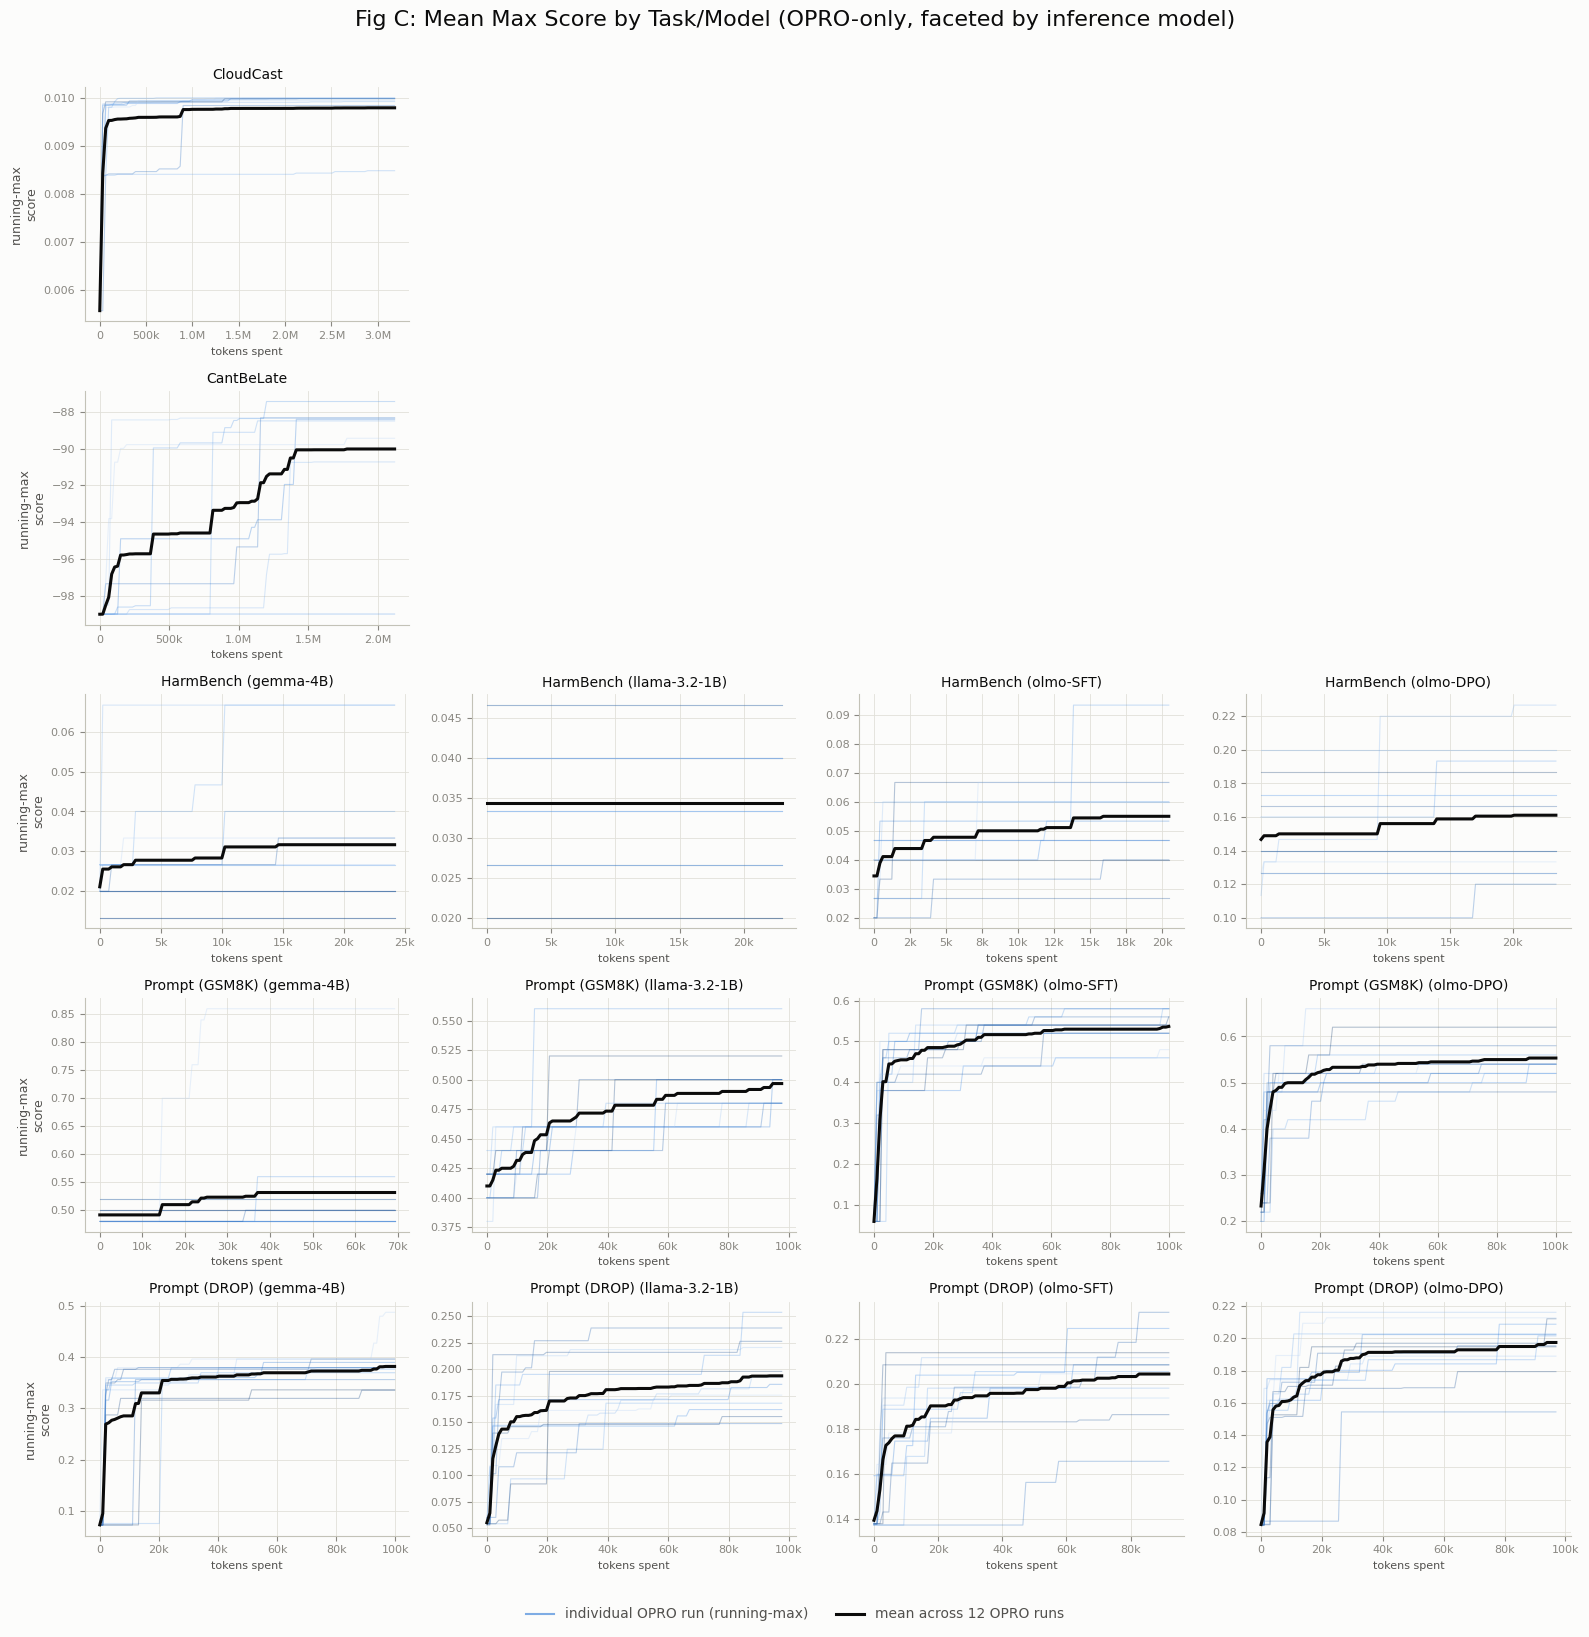

In [17]:
"""Fig C: per-task mean running-max score (OPRO-only), faceted by
inference model for harmbench/prompt -- same 5x4 grid as Fig A (see the
markdown cell above), Visual 1 row 2's metric instead of Visual 2's
diversity metric, no tercile stratification.

Depends on Fig A's cell having already run (reuses FIG_A_ROWS,
FIG_A_MODEL_ORDER, multimodel_runs) plus the notebook's own runs_by_column
global -- doesn't redefine or mutate any of Fig A's names.
"""


def score_trajectories_for(
    by_optimizer: dict[str, list[dict]],
) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    """opro-only per_optimizer -> (tokens, running-max score) -- no
    embeddings involved, unlike Fig A's diversity_trajectories_for.
    """
    per_optimizer = {}
    for label, records in by_optimizer.items():
        tokens = np.array([r['cumulative_tokens_spent'] for r in records], dtype=float)
        scores = np.array([r['score'] for r in records], dtype=float)
        per_optimizer[label] = (tokens, running_max(scores))
    return per_optimizer


def draw_mean_max_score_panel(
    ax: plt.Axes, per_optimizer: dict[str, tuple[np.ndarray, np.ndarray]],
) -> None:
    """One panel: thin per-run running-max lines (color_for, faint) + one
    bold dark mean-of-running-max line -- same style as Visual 1 row 2's
    "mean across all 14" line (cell 10 above), restricted to the 12
    OPRO-only trajectories passed in.
    """
    ax.set_facecolor(SURFACE)

    grid_end = min(tokens.max() for tokens, _ in per_optimizer.values())  # safe overlap only
    grid = np.linspace(0, grid_end, 100) if grid_end > 0 else np.array([0.0])

    interpolated = []
    for label, (tokens, cummax) in per_optimizer.items():
        color = color_for(label)
        resampled = step_interpolate(tokens, cummax, grid)
        interpolated.append(resampled)
        ax.plot(grid, resampled, color=color, linewidth=0.8, alpha=0.3, zorder=2)

    mean_series = np.nanmean(np.vstack(interpolated), axis=0)
    ax.plot(grid, mean_series, color=INK_PRIMARY, linewidth=2.2, zorder=5)

    ax.xaxis.set_major_formatter(tokens_fmt)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    for spine in ax.spines.values():
        spine.set_color(BASELINE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(color=GRIDLINE, linewidth=0.6)
    ax.set_axisbelow(True)


fig, axes = plt.subplots(5, 4, figsize=(16, 16), facecolor=SURFACE, sharex=False, sharey=False)

for row_idx, (row_label, column_key, task_name, is_multi) in enumerate(FIG_A_ROWS):
    for col_idx in range(4):
        ax = axes[row_idx, col_idx]

        if not is_multi:
            if col_idx > 0:
                ax.axis('off')
                continue
            by_optimizer = {
                label: records for label, records in runs_by_column[column_key].items()
                if label.startswith('opro')
            }
            title = row_label
        else:
            model_label = FIG_A_MODEL_ORDER[col_idx]
            by_optimizer = multimodel_runs[(task_name, model_label)].get(column_key, {})
            if not by_optimizer:
                ax.axis('off')
                continue
            title = f'{row_label} ({model_label})'

        per_optimizer = score_trajectories_for(by_optimizer)
        draw_mean_max_score_panel(ax, per_optimizer)
        ax.set_title(title, color=INK_PRIMARY, fontsize=10)
        ax.set_xlabel('tokens spent', color=INK_SECONDARY, fontsize=8)

    axes[row_idx, 0].set_ylabel('running-max\nscore', color=INK_SECONDARY, fontsize=9)

fig_c_legend_handles = [
    plt.Line2D([0], [0], color=BLUE_RAMP[6], lw=1.5, alpha=0.6, label='individual OPRO run (running-max)'),
    plt.Line2D([0], [0], color=INK_PRIMARY, lw=2.2, label='mean across 12 OPRO runs'),
]
fig.legend(
    handles=fig_c_legend_handles, loc='lower center', ncol=2,
    frameon=False, labelcolor=INK_SECONDARY, fontsize=10,
    bbox_to_anchor=(0.5, -0.01),
)

fig.suptitle(
    'Fig C: Mean Max Score by Task/Model (OPRO-only, faceted by inference model)',
    color=INK_PRIMARY, fontsize=16, y=1.005,
)
fig.tight_layout(rect=(0, 0.02, 1, 1))

fig.savefig(
    os.path.join(FIGS_DIR, 'figC_mean_max_score.pdf'),
    bbox_inches='tight',
)
print(f'saved to {os.path.join(FIGS_DIR, "figC_mean_max_score.pdf")}')

plt.show()
